# TP2 : Reconocimiento de Actividades Humanas con Machine Learning

## Contexto general

En este trabajo práctico vamos a abordar un problema clásico de **clasificación supervisada**: predecir la actividad que está realizando una persona a partir de mediciones obtenidas por sensores de un smartphone ([documentación del dataset](https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones)).

Este tipo de problema aparece en muchas aplicaciones reales de ingeniería y ciencia de datos, por ejemplo:

- monitoreo de actividad física,
- salud digital,
- sistemas de asistencia,
- interfaces inteligentes,
- dispositivos *wearables* y móviles.

La idea central es construir un flujo de trabajo completo de *machine learning*, desde la exploración de los datos hasta la evaluación de distintos modelos de clasificación.

## Objetivos del TP

A lo largo de este notebook se espera que puedan:

- comprender la estructura general del problema,
- explorar y analizar el conjunto de datos,
- preparar las variables para el modelado,
- aplicar técnicas de reducción de dimensionalidad (PCA),
- entrenar distintos clasificadores (regresion logistica, arbol de decision y random forrest),
- comparar resultados y discutir ventajas y limitaciones de cada enfoque.

## Consigna general

No se busca solamente ejecutar código, sino también **interpretar** qué se está haciendo en cada etapa y **justificar** las decisiones tomadas.

En particular, al finalizar el TP deberían poder responder preguntas como:

- ¿qué tipo de problema de aprendizaje automático estamos resolviendo?
- ¿qué información contienen las variables de entrada?
- ¿por qué ciertas transformaciones son útiles para algunos modelos y no para otros?
- ¿cómo comparar modelos más allá de una única métrica?


### **Consignas presentacion:** La presentación debe tener un máximo de 4 diapositivas y una duración aproximada de **5 minutos**. La estructura de las diapositivas debe ser la siguiente:
  1. Presentación del grupo y del problema a resolver.
  2. Datos, pre-procesamiento y PCA.
  3. Modelado.
  4. Resultados/Conclusiones.

Durante la presentación deberán explicar claramente las siguientes etapas del trabajo:
- Análisis exploratorio de datos (EDA):
Qué observaron en los datos: estructura del dataset, variables importantes, valores faltantes, distribuciones, posibles outliers y relaciones entre variables.

- PCA : Nuevas variables, varianza acumulada y cantidad de variables.

- Modelos regresion logistica, Árbol de Decisión y Random Forrest:
Qué modelos probaron, por qué los eligieron y cómo ajustaron sus parámetros o configuraciones para mejorar el rendimiento.

- Evaluación y testeo del modelo:
Cómo evaluaron el modelo, qué métricas utilizaron y qué resultados obtuvieron en el conjunto de test.

El objetivo de esta presentación es mostrar que realmente comprendieron el proceso que realizaron y que pueden explicarlo de manera clara.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
import seaborn as sns


In [ ]:
# Cargar datasets de train y test
df_train = pd.read_csv('https://raw.githubusercontent.com/juanserrano90/SIA_itba/refs/heads/main/TP2/train.csv')
df_test = pd.read_csv('https://raw.githubusercontent.com/juanserrano90/SIA_itba/refs/heads/main/TP2/test.csv')

### Descripción del conjunto de datos

El dataset utilizado corresponde a un problema de **reconocimiento de actividad humana**. Cada observación representa una ventana de señales registradas por sensores inerciales de un teléfono móvil, y la variable objetivo indica la actividad realizada por la persona.

En el conjunto de datos aparecen dos tipos de información importantes:

- una columna con la **actividad** a predecir,
- una columna que identifica al **sujeto**,
- un conjunto grande de variables numéricas derivadas de las señales medidas por los sensores.

### Observación importante

En este TP el objetivo principal es predecir la variable **`Activity`**.  
La columna **`subject`** no describe directamente el movimiento, sino la identidad del participante. *Por eso conviene pensar críticamente si debe utilizarse o no como predictor.*

## Hoja de ruta del análisis

El trabajo seguirá, de manera general, los siguientes pasos:

1. inspección inicial de los datos,
2. análisis exploratorio,
3. preparación de variables,
4. reducción de dimensionalidad,
5. entrenamiento de modelos,
6. evaluación y comparación de resultados.

# 1. Análisis Exploratorio de Datos (EDA)
### Preguntas orientadoras

Mientras ejecutan las celdas, intenten responder:

a) ¿Cuántas observaciones y cuántas variables hay? \
b) ¿Todas las variables predictoras son numéricas?\
c) ¿Hay datos faltantes?\
d) ¿Las clases parecen estar balanceadas o desbalanceadas?\
e) ¿Qué implicancias podría tener esto para el entrenamiento?\
f) ¿Cuántos sujetos únicos hay?

El análisis exploratorio no solo sirve para “mirar” los datos: también ayuda a anticipar posibles decisiones de preprocesamiento y modelado.

El dataset utilizado corresponde a un problema de reconocimiento de actividades humanas (Human Activity Recognition). Contiene datos obtenidos a partir de los sensores de un smartphone (acelerómetro y giroscopio) colocado en la cintura de 30 voluntarios mientras realizaban seis actividades distintas: caminar, subir escaleras, bajar escaleras, sentarse, pararse y acostarse.

Las señales fueron registradas a 50 Hz y preprocesadas mediante filtros para eliminar ruido y separar componentes de movimiento y gravedad. A partir de ventanas temporales de 2.56 segundos se extrajeron 561 variables numéricas en dominio temporal y frecuencial.


In [ ]:
# Código
df_train.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


In [ ]:
df_train.shape

(7352, 563)

El conjunto de entrenamiento contiene 7352 observaciones y 563 variables, incluyendo la actividad (`Activity`) y el identificador del sujeto (`subject`).

In [ ]:
df_test.shape

(2947, 563)

El conjunto de testeo cuenta con 2947 observaciones y 563 variables.

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Columns: 563 entries, tBodyAcc-mean()-X to Activity
dtypes: float64(561), int64(1), object(1)
memory usage: 31.6+ MB


In [ ]:
df_train.dtypes

,0
tBodyAcc-mean()-X,float64
tBodyAcc-mean()-Y,float64
tBodyAcc-mean()-Z,float64
tBodyAcc-std()-X,float64
tBodyAcc-std()-Y,float64
...,...
"angle(X,gravityMean)",float64
"angle(Y,gravityMean)",float64
"angle(Z,gravityMean)",float64
subject,int64


In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2947 entries, 0 to 2946
Columns: 563 entries, tBodyAcc-mean()-X to Activity
dtypes: float64(561), int64(1), object(1)
memory usage: 12.7+ MB


In [ ]:
df_test.dtypes

,0
tBodyAcc-mean()-X,float64
tBodyAcc-mean()-Y,float64
tBodyAcc-mean()-Z,float64
tBodyAcc-std()-X,float64
tBodyAcc-std()-Y,float64
...,...
"angle(X,gravityMean)",float64
"angle(Y,gravityMean)",float64
"angle(Z,gravityMean)",float64
subject,int64


La gran mayoría de las variables son numéricas (561 variables float64 y 1 variable int64 correspondiente al identificador del sujeto), mientras que solo una variable es categórica (Activity), que representa la actividad a predecir.

In [ ]:
duplicados_train = df_train.duplicated().sum()
duplicados_test = df_test.duplicated().sum()

In [ ]:
print(f"Filas duplicadas en el conjunto de entrenamiento: {duplicados_train}")
print(f"Filas duplicadas en el conjunto de prueba: {duplicados_test}")

Filas duplicadas en el conjunto de entrenamiento: 0
Filas duplicadas en el conjunto de prueba: 0


In [ ]:
cantinicial=len(df_train)
print(f"Cantidad inicial de filas únicas del dataset de entrenamiento: {cantinicial}")
cantinicial_test=len(df_test)
print(f"Cantidad inicial de filas únicas del dataset de prueba: {cantinicial_test}")

Cantidad inicial de filas únicas del dataset de entrenamiento: 7352
Cantidad inicial de filas únicas del dataset de prueba: 2947


In [ ]:
df_train.isnull().values.any()

np.False_

In [ ]:
df_test.isnull().values.any()

np.False_

No se encontraron valores faltantes ni filas duplicadas en el conjunto de datos. Esto indica una buena calidad del dataset y evita la necesidad de aplicar técnicas adicionales de imputación o limpieza de datos antes del modelado.

<Axes: >

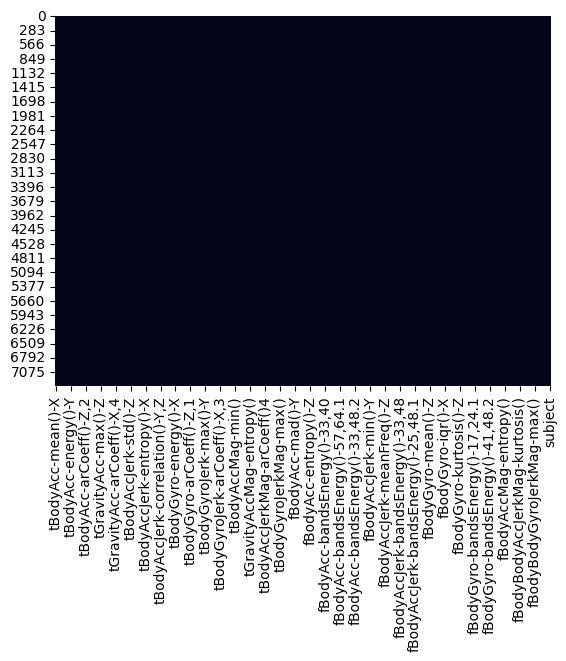

In [ ]:
sns.heatmap(df_train.isnull(), cbar=False)  # Mapa de calor de valores faltantes en el conjunto de entrenamiento

A continuación evaluamos si las clases están desbalanceadas. Para ello evaluamos la proporción de cada clase en los dataset de test y entrenamiento, y a su vez presentamos un gráfico de barras para una mejor visualización de la distribución de las clases.

In [ ]:
df_train['Activity'].value_counts(normalize=True)

,proportion
Activity,
LAYING,0.191376
STANDING,0.186888
SITTING,0.174918
WALKING,0.166757
WALKING_UPSTAIRS,0.145947
WALKING_DOWNSTAIRS,0.134113


In [ ]:
df_test['Activity'].value_counts(normalize=True)

,proportion
Activity,
LAYING,0.182219
STANDING,0.180523
WALKING,0.168307
SITTING,0.166610
WALKING_UPSTAIRS,0.159824
WALKING_DOWNSTAIRS,0.142518


In [ ]:
# Hacer lista con los nombres de las actividades
actividades = df_train['Activity'].unique()
print("Actividades presentes en el dataset de entrenamiento:")
print(actividades)

Actividades presentes en el dataset de entrenamiento:
['STANDING' 'SITTING' 'LAYING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']


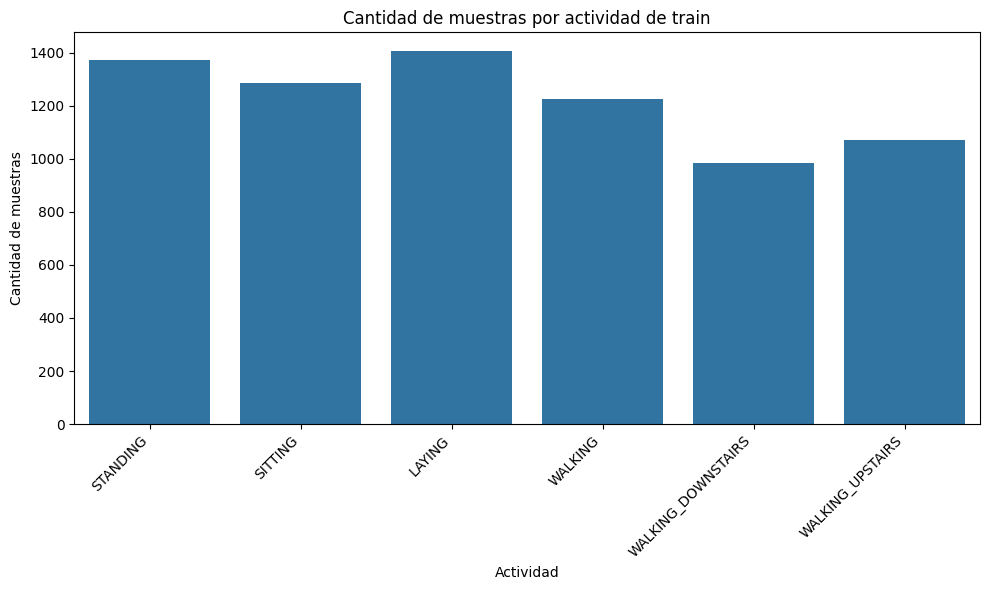

In [ ]:
# Grafico de barras de la cantidad de muestras por actividad de train
plt.figure(figsize=(10, 6))
sns.countplot(x='Activity', data=df_train, order=actividades)
plt.title('Cantidad de muestras por actividad de train')
plt.xlabel('Actividad')
plt.ylabel('Cantidad de muestras')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

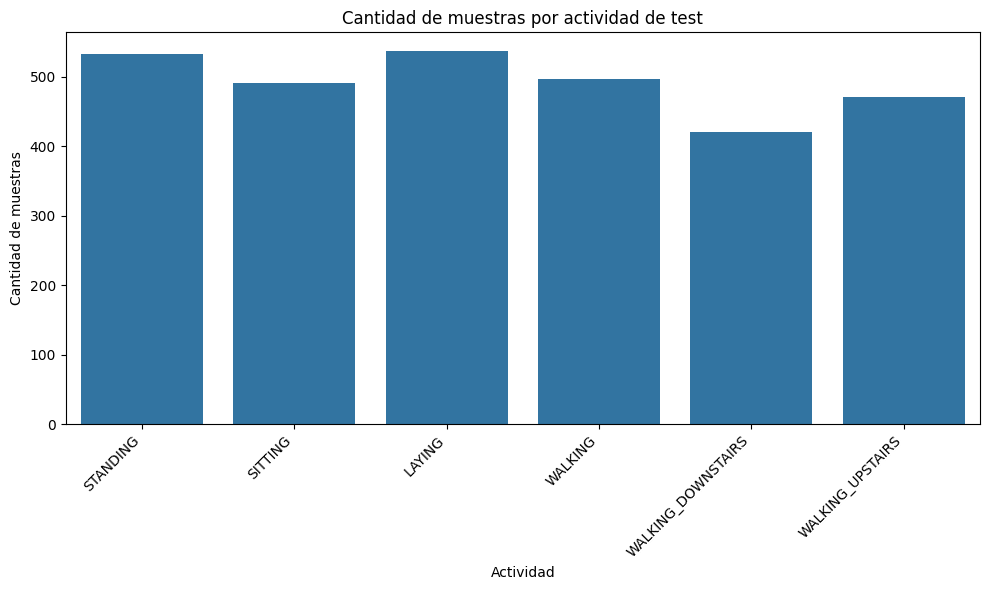

In [ ]:
# Grafico de barras de la cantidad de muestras por actividad de test
plt.figure(figsize=(10, 6))
sns.countplot(x='Activity', data=df_test, order=actividades)
plt.title('Cantidad de muestras por actividad de test')
plt.xlabel('Actividad')
plt.ylabel('Cantidad de muestras')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Las clases se encuentran relativamente balanceadas tanto en el conjunto de entrenamiento como en el de test. Ninguna actividad domina fuertemente sobre las demás, ya que las proporciones de cada clase se mantienen entre aproximadamente 13% y 19%. Además, la distribución entre train y test es muy similar, lo que sugiere que la partición de los datos fue consistente y representativa.

Esto es favorable para el entrenamiento de los modelos, ya que reduce el riesgo de sesgo hacia una clase mayoritaria y permite utilizar métricas generales como accuracy junto con otras métricas de clasificación.


Evaluamos también la cantidad de sujetos presentes en los datos.

In [ ]:
df_train['subject'].nunique()

21

In [ ]:
# Hacer lista con los nombres de los sujetos
subjects_train = df_train['subject'].unique()
print("Sujetos presentes en el dataset de entrenamiento:")
print(subjects_train)

Sujetos presentes en el dataset de entrenamiento:
[ 1  3  5  6  7  8 11 14 15 16 17 19 21 22 23 25 26 27 28 29 30]


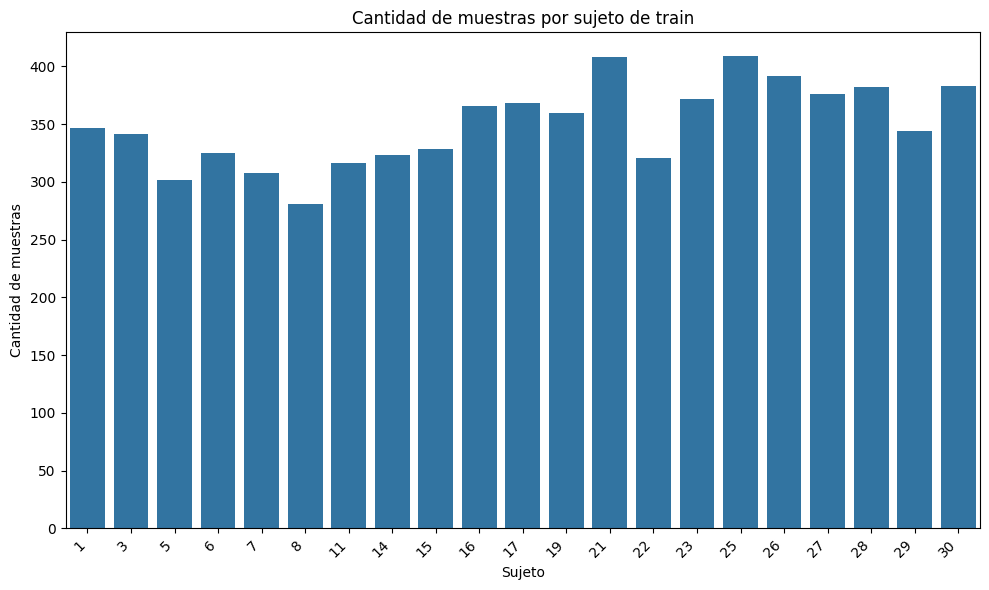

In [ ]:
# Grafico de barras de la cantidad de muestras por sujeto de train
plt.figure(figsize=(10, 6))
sns.countplot(x='subject', data=df_train, order=subjects_train)
plt.title('Cantidad de muestras por sujeto de train')
plt.xlabel('Sujeto')
plt.ylabel('Cantidad de muestras')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
df_test['subject'].nunique()

9

In [ ]:
subjects_test = df_test['subject'].unique()
print("Sujetos presentes en el dataset de testeo:")
print(subjects_test)

Sujetos presentes en el dataset de testeo:
[ 2  4  9 10 12 13 18 20 24]


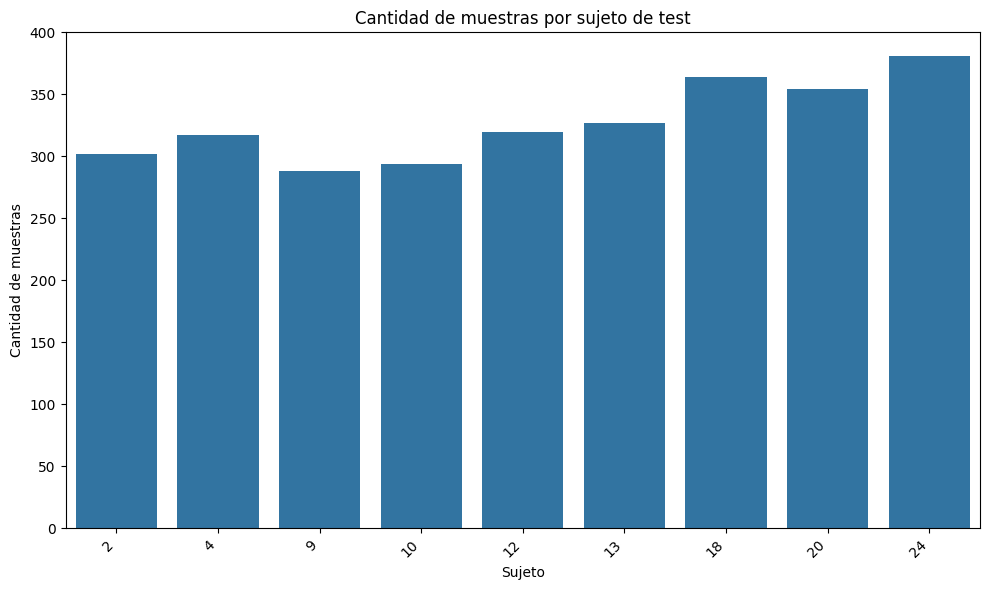

In [ ]:
# Grafico de barras de la cantidad de muestras por sujeto de test
plt.figure(figsize=(10, 6))
sns.countplot(x='subject', data=df_test, order=subjects_test)
plt.title('Cantidad de muestras por sujeto de test')
plt.xlabel('Sujeto')
plt.ylabel('Cantidad de muestras')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Entonces, tenemos un total de 21 sujetos en el conjunto de entrenamiento y 9 en el conjunto de testeo. Para ambos casos, se tiene una cantidad de muestras variable para los distintos sujetos, tal como se puede observar en los gráficos.

Lo importante es que no hay overlap, es decir, los sujetos de train son completamente distintos a los de test. Esto es crítico porque evita data leakage. Esto es más realista porque en la práctica queremos que el modelo generalice a nuevas personas, no que memorice ejemplos de las mismos sujetos.

También analizamos la presencia de outliers:

In [ ]:
# Función para identificar y filtrar outliers con iqr
def encontrar_outliers_iqr(df, cols):
  q1 = df[cols].quantile(0.25)
  q3 = df[cols].quantile(0.75)
  iqr = q3 - q1
  iqr_limite_inf = q1 - 1.5*iqr
  iqr_limite_sup = q3 + 1.5*iqr

  mask = (df[cols] < iqr_limite_inf) | (df[cols] > iqr_limite_sup)

  print("Número de outliers:\n", mask.sum())

  return df[~mask.any(axis=1)]

In [ ]:
# Seleccionar todas las columnas excepto 'Activity' y 'subject' para PCA
features = df_train.drop(['Activity', 'subject'], axis=1)

df_train_sinoutliers = encontrar_outliers_iqr(df_train, features.columns)

Número de outliers:
 tBodyAcc-mean()-X                       1795
tBodyAcc-mean()-Y                       1122
tBodyAcc-mean()-Z                       1180
tBodyAcc-std()-X                           2
tBodyAcc-std()-Y                           0
                                        ... 
angle(tBodyGyroMean,gravityMean)           0
angle(tBodyGyroJerkMean,gravityMean)       0
angle(X,gravityMean)                    1437
angle(Y,gravityMean)                     776
angle(Z,gravityMean)                     705
Length: 561, dtype: int64


Se realizó una detección exploratoria de outliers utilizando el criterio del rango intercuartílico (IQR), observándose valores extremos en varias variables. Sin embargo, en este tipo de dataset dichos valores no necesariamente representan errores o datos anómalos, sino que pueden reflejar patrones reales de movimiento humano capturados por los sensores.

Además, las variables del conjunto de datos ya corresponden a características previamente procesadas a partir de señales del acelerómetro y giroscopio, por lo que los valores extremos pueden contener información relevante para distinguir actividades. Por este motivo, se decidió no eliminar outliers y continuar el análisis utilizando el dataset completo.


# 2. Preparación de los datos

 Guía orientadora:
* Codificar la variable objetivo 'Activity' en el conjunto de entrenamiento y testeo.
* Verificar la codificación de 'Activity' en las primeras 5 instancias de entrenamiento, así como que se hayan codificado correctamente todas las actividades presentes en el dataset.
* Escalar las variables numéricas.
* ¿Qué variables del dataset eligen como predictoras para su modelo y por qué?

En primer lugar pasamos la variable Activity, que es categórica, a numérica

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(df_train['Activity'])
y_test = le.transform(df_test['Activity'])

In [ ]:
print(df_train['Activity'].head())
print(y_train[:5])

0    STANDING
1    STANDING
2    STANDING
3    STANDING
4    STANDING
Name: Activity, dtype: object
[2 2 2 2 2]


In [ ]:
print(le.classes_)

['LAYING' 'SITTING' 'STANDING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']


In [ ]:
for i, clase in enumerate(le.classes_):
    print(f"{clase} -> {i}")

LAYING -> 0
SITTING -> 1
STANDING -> 2
WALKING -> 3
WALKING_DOWNSTAIRS -> 4
WALKING_UPSTAIRS -> 5


Entonces, a variable objetivo `Activity` fue codificada numéricamente utilizando `LabelEncoder`, asignando un valor entero a cada actividad presente en el dataset. La codificación resultante fue la siguiente: `LAYING = 0`, `SITTING = 1`, `STANDING = 2`, `WALKING = 3`, `WALKING_DOWNSTAIRS = 4` y `WALKING_UPSTAIRS = 5`.


A continuación, para realizar el escalado nos quedamos sólo con las features numéricas, excluyendo `subject` y `Activity`

In [ ]:
# Seleccionamos únicamente las variables predictoras
features = [col for col in df_train.columns if col not in ['Activity', 'subject']]

# Creamos los datasets de features
df_features_train = df_train[features]
df_features_test = df_test[features]

# Escalado
scaler = StandardScaler()

X_features_train_scaled = scaler.fit_transform(df_features_train) # Escalado de los datos de train (fit y transform)
X_features_test_scaled = scaler.transform(df_features_test) # Escalado de los datos de test (solo transform!)

In [ ]:
# Visualización
print("Datos originales (Train):\n", df_features_train.head(2))
print("\nDatos escalados (Train):\n", X_features_train_scaled[:2, :5])

Datos originales (Train):
    tBodyAcc-mean()-X  tBodyAcc-mean()-Y  tBodyAcc-mean()-Z  tBodyAcc-std()-X  \
0           0.288585          -0.020294          -0.132905         -0.995279   
1           0.278419          -0.016411          -0.123520         -0.998245   

   tBodyAcc-std()-Y  tBodyAcc-std()-Z  tBodyAcc-mad()-X  tBodyAcc-mad()-Y  \
0         -0.983111         -0.913526         -0.995112         -0.983185   
1         -0.975300         -0.960322         -0.998807         -0.974914   

   tBodyAcc-mad()-Z  tBodyAcc-max()-X  ...  fBodyBodyGyroJerkMag-meanFreq()  \
0         -0.923527         -0.934724  ...                        -0.074323   
1         -0.957686         -0.943068  ...                         0.158075   

   fBodyBodyGyroJerkMag-skewness()  fBodyBodyGyroJerkMag-kurtosis()  \
0                        -0.298676                        -0.710304   
1                        -0.595051                        -0.861499   

   angle(tBodyAccMean,gravity)  angle(tBodyAccJe

In [ ]:
print("\nDatos originales (Test):\n", df_features_test.head(2))
print("\nDatos escalados (Test):\n", X_features_test_scaled[:2,:5])


Datos originales (Test):
    tBodyAcc-mean()-X  tBodyAcc-mean()-Y  tBodyAcc-mean()-Z  tBodyAcc-std()-X  \
0           0.257178          -0.023285          -0.014654         -0.938404   
1           0.286027          -0.013163          -0.119083         -0.975415   

   tBodyAcc-std()-Y  tBodyAcc-std()-Z  tBodyAcc-mad()-X  tBodyAcc-mad()-Y  \
0         -0.920091         -0.667683         -0.952501         -0.925249   
1         -0.967458         -0.944958         -0.986799         -0.968401   

   tBodyAcc-mad()-Z  tBodyAcc-max()-X  ...  fBodyBodyGyroJerkMag-meanFreq()  \
0         -0.674302         -0.894088  ...                         0.071645   
1         -0.945823         -0.894088  ...                        -0.401189   

   fBodyBodyGyroJerkMag-skewness()  fBodyBodyGyroJerkMag-kurtosis()  \
0                        -0.330370                        -0.705974   
1                        -0.121845                        -0.594944   

   angle(tBodyAccMean,gravity)  angle(tBodyAccJe

In [ ]:
# Verificar que el escalado funcionó correctamente
print("Verificación del escalado:")
print("=" * 60)
print(f"Media de variables escaladas (debe ser ~0): {X_features_train_scaled.mean().mean():.6f}")
print(f"Desv. Est. de variables escaladas (debe ser ~1): {X_features_train_scaled.std().mean():.6f}")
print("\nMuestras de min/max valores escalados:")
print(f"Valor mínimo: {X_features_train_scaled.min().min():.4f}")
print(f"Valor máximo: {X_features_train_scaled.max().max():.4f}")

Verificación del escalado:
Media de variables escaladas (debe ser ~0): 0.000000
Desv. Est. de variables escaladas (debe ser ~1): 1.000000

Muestras de min/max valores escalados:
Valor mínimo: -24.0715
Valor máximo: 34.1941


In [ ]:
X_features_train_scaled.shape

(7352, 561)

In [ ]:
X_features_test_scaled.shape

(2947, 561)

Las variables numéricas fueron escaladas utilizando `StandardScaler`, con el objetivo de centrar los datos en media cero y desviación estándar uno. Este paso resulta especialmente importante para métodos sensibles a la escala de las variables, como PCA y regresión logística, ya que evita que variables con magnitudes mayores dominen el entrenamiento del modelo.


Para el modelado se utilizarán como variables predictoras todas las características numéricas derivadas de las señales del acelerómetro y giroscopio. Estas variables contienen información sobre el movimiento y la orientación del cuerpo, por lo que resultan relevantes para la clasificación de actividades humanas. Son las que definimos finalmente como `X_features_train_scaled` y `X_features_test_scaled`.

La variable Activity fue utilizada como variable objetivo y codificada numéricamente mediante Label Encoding para poder ser utilizada por los modelos de machine learning.

Por otro lado, la variable subject no se utilizará como predictora, ya que representa únicamente la identidad del participante y no información relacionada directamente con la actividad realizada. Incluirla podría generar sesgos y reducir la capacidad de generalización del modelo.

In [ ]:
# Guardar los nombres de las columnas para usar en PCA
feature_names = df_features_train.columns
df_features_train_scaled = pd.DataFrame(X_features_train_scaled, columns=feature_names)
df_features_train_scaled.head(10)

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,0.200642,-0.063683,-0.419628,-0.868814,-0.939441,-0.737529,-0.859817,-0.939019,-0.766437,-0.856036,...,-0.795359,0.025960,-0.276399,-0.360603,0.062940,-0.778427,-0.026080,-0.687219,0.407946,-0.007568
1,0.055948,0.031486,-0.253908,-0.875426,-0.923902,-0.849304,-0.868531,-0.921998,-0.848928,-0.871359,...,0.130614,-0.897357,-0.767990,0.133011,-0.021461,-1.218805,1.484470,-0.694138,0.409117,0.007875
2,0.073515,-0.043416,-0.076295,-0.869039,-0.907760,-0.893785,-0.863137,-0.898854,-0.896701,-0.863323,...,1.152336,-0.260878,-0.438316,-0.377840,0.391976,0.151207,1.704201,-0.702239,0.410288,0.026502
3,0.066696,-0.208422,-0.249712,-0.870626,-0.940022,-0.921805,-0.864503,-0.938124,-0.925279,-0.863323,...,1.112769,0.591045,0.463155,-0.135025,-0.033637,1.037851,-1.003019,-0.701684,0.414650,0.031714
4,0.030469,0.027587,-0.109848,-0.875188,-0.934878,-0.921343,-0.867384,-0.931789,-0.928028,-0.870260,...,-0.149577,-0.138515,-0.240313,0.340406,0.268486,1.125918,-1.276282,-0.700152,0.425463,0.045225
5,0.038582,0.186180,0.070699,-0.873397,-0.954117,-0.933139,-0.865748,-0.953493,-0.940363,-0.870260,...,-0.419721,-0.742707,-0.713107,0.219586,-0.324856,0.437830,-0.757922,-0.703603,0.424358,0.051552
6,0.070680,-0.047671,-0.015559,-0.872474,-0.907757,-0.903754,-0.864275,-0.903852,-0.910339,-0.867538,...,0.081880,0.279795,0.197889,-0.657546,-0.519341,0.009718,-0.384001,-0.708525,0.415441,0.048386
7,0.041908,-0.313491,-0.286403,-0.871668,-0.906847,-0.900094,-0.863055,-0.904297,-0.910015,-0.867538,...,0.044181,0.700031,0.661908,-0.087811,1.320191,-0.938078,0.990421,-0.706310,0.420848,0.052091
8,0.039929,-0.099375,-0.205007,-0.873382,-0.895938,-0.905077,-0.865674,-0.885617,-0.913390,-0.866823,...,0.752040,0.117163,0.170041,0.012681,0.175674,-0.399562,0.258981,-0.700359,0.438343,0.068615
9,0.086790,0.189550,0.054314,-0.867755,-0.918844,-0.911221,-0.860507,-0.919424,-0.916439,-0.865776,...,0.566145,2.014197,2.489717,-0.086925,-0.289813,-0.808199,-0.135349,-0.700990,0.442807,0.079173


In [ ]:
df_features_test_scaled = pd.DataFrame(X_features_test_scaled, columns=feature_names)
df_features_test_scaled.head(10)

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,-0.246388,-0.136979,1.668462,-0.742061,-0.814056,-0.150313,-0.759330,-0.819786,-0.164580,-0.781407,...,-0.213757,-0.072779,-0.262320,-0.006596,0.358560,-1.372126,0.579845,-0.450322,0.733571,-0.005244
1,0.164235,0.111059,-0.175548,-0.824544,-0.908299,-0.812607,-0.840212,-0.908595,-0.820280,-0.781407,...,-2.097734,0.576855,0.098679,-0.273719,0.034161,-0.728470,1.938673,-0.407493,0.748840,-0.098112
2,0.014187,-0.204740,-0.159111,-0.865561,-0.913208,-0.855099,-0.858146,-0.913397,-0.862926,-0.864367,...,-0.248637,0.363213,-0.050207,-0.129586,0.446413,0.091042,0.316041,-0.416639,0.744605,-0.081803
3,-0.059637,-0.365579,-0.147960,-0.867620,-0.919858,-0.865472,-0.860199,-0.921086,-0.876002,-0.863173,...,-0.034259,-0.116542,-0.360349,-0.076465,0.339639,0.544845,0.632687,-0.409180,0.758155,-0.073784
4,0.004908,-0.248785,-0.359980,-0.865636,-0.908274,-0.892234,-0.857457,-0.903555,-0.896405,-0.863173,...,-0.984174,-0.709294,-0.719531,-0.032386,-0.094211,1.196836,-0.235517,-0.396070,0.780371,-0.062135
5,0.067351,-0.022667,-0.084069,-0.866979,-0.914186,-0.861234,-0.858574,-0.910816,-0.868756,-0.861789,...,-0.166113,-0.581042,-0.755197,-0.309903,0.104094,1.236241,-0.138584,-0.391324,0.794402,-0.042837
6,0.074836,-0.014105,0.090783,-0.870019,-0.925998,-0.890872,-0.861901,-0.919427,-0.901009,-0.861789,...,0.585893,0.664055,0.760844,-0.943591,-0.006789,1.183353,-0.685836,-0.391850,0.795700,-0.037802
7,0.001600,-0.179861,-0.135788,-0.869518,-0.937369,-0.908877,-0.860356,-0.935521,-0.913946,-0.868046,...,0.352646,-0.096932,-0.153024,-0.101584,-0.482336,0.705147,-0.754679,-0.389311,0.798051,-0.040096
8,-0.027889,-0.079852,-0.094143,-0.872169,-0.925107,-0.912064,-0.864338,-0.919572,-0.916232,-0.868046,...,0.630077,-1.004986,-0.741161,0.403674,-0.084212,-0.313230,0.195213,-0.382676,0.809525,-0.032163
9,0.017900,0.179462,0.165370,-0.875710,-0.947046,-0.922634,-0.868190,-0.947158,-0.929582,-0.872633,...,1.032541,-0.506976,-0.377618,0.442152,-0.079579,-0.591225,0.730478,-0.380175,0.814324,-0.027762


# 3. Reducción de dimensionalidad con PCA

El dataset contiene un número elevado de variables. Cuando trabajamos con muchas dimensiones, pueden aparecer varios desafíos: mayor costo computacional, redundancia entre variables, dificultad para interpretar los datos, o riesgo de sobreajuste en algunos modelos.

Para abordar este problema se utilizará **PCA (Análisis de Componentes Principales)**, una técnica que transforma las variables originales en un nuevo conjunto de componentes linealmente independientes que capturan gran parte de la variabilidad del sistema.

Aplicar PCA para reducir la dimensionalidad del dataset antes de entrenar.

### Guía orientadora

- ¿Cuánta varianza explican las primeras componentes?
- ¿Cómo se ve la varianza acumulada en función del número de componentes?
- ¿Cuántas componentes van a conservar?
- ¿Qué se gana y qué se pierde al reducir dimensionalidad?

In [ ]:
# PCA con todas las componentes para analizar la varianza explicada por cada una
pca_all = PCA(random_state=42)
PCA_scores = pca_all.fit_transform(df_features_train_scaled)
Val_Explica_Variables= np.cumsum(pca_all.explained_variance_ratio_)

`fit_transform()` devuelve una matriz donde cada fila representa una muestra del conjunto de entrenamiento proyectada en el nuevo espacio generado por PCA, mientras que cada columna corresponde a una componente principal.

Por otro lado, `explained_variance_ratio_` indica la proporción de varianza explicada por cada componente principal. Luego, utilizando `np.cumsum()`, se calcula la varianza acumulada explicada al incorporar progresivamente más componentes.


In [ ]:
print("PCA Scores:\n", PCA_scores)
PCA_scores.shape

PCA Scores:
 [[-1.61385437e+01  2.15202401e+00 -3.14478025e+00 ...  3.80817706e-09
  -3.88124966e-08  8.79550712e-10]
 [-1.52961943e+01  1.38714378e+00  6.82221071e-01 ...  1.85359886e-08
   2.90590205e-09 -3.88680451e-09]
 [-1.51370186e+01  2.47335094e+00  1.75664057e+00 ...  1.31011966e-08
   1.29964928e-09  1.21332161e-08]
 ...
 [ 1.43334359e+01 -1.22607119e+01 -4.02594620e+00 ... -2.52213037e-08
   9.34444371e-10 -1.85055609e-08]
 [ 1.28760189e+01 -1.40712559e+01 -2.91606098e+00 ...  5.49286838e-10
   4.58481406e-09 -1.85777502e-08]
 [ 1.30161037e+01 -1.22442612e+01 -1.33604965e+00 ... -1.40699228e-08
  -2.13427866e-08 -7.18370614e-09]]


(7352, 561)

In [ ]:
print("Varianza explicada por cada componente:\n", pca_all.explained_variance_ratio_)
pca_all.explained_variance_ratio_.shape

Varianza explicada por cada componente:
 [5.07811723e-01 6.58068027e-02 2.80643677e-02 2.50395275e-02
 1.88828501e-02 1.72400642e-02 1.37101147e-02 1.19907768e-02
 9.95859511e-03 9.65086590e-03 8.60051649e-03 8.00280950e-03
 7.63996369e-03 6.45328924e-03 6.32324346e-03 5.99722090e-03
 5.86750302e-03 5.75407392e-03 5.67921047e-03 5.27295779e-03
 5.00362925e-03 4.88408406e-03 4.78205784e-03 4.68562930e-03
 4.49289260e-03 4.21027243e-03 4.17978682e-03 4.05570369e-03
 3.88524168e-03 3.87018044e-03 3.65958878e-03 3.54553381e-03
 3.47942606e-03 3.37187109e-03 3.29676999e-03 3.28215050e-03
 3.20529478e-03 2.95614939e-03 2.86722415e-03 2.85074548e-03
 2.68766324e-03 2.65619859e-03 2.63405989e-03 2.58850596e-03
 2.49054872e-03 2.46954034e-03 2.40679913e-03 2.36115075e-03
 2.30278857e-03 2.27567245e-03 2.20164699e-03 2.13466984e-03
 2.07704456e-03 2.02496620e-03 1.99779441e-03 1.97750625e-03
 1.94273627e-03 1.90237160e-03 1.88064891e-03 1.86215970e-03
 1.81466544e-03 1.77380987e-03 1.76085074e-0

(561,)

In [ ]:
print("Varianza explicada acumulada:\n", Val_Explica_Variables)

Varianza explicada acumulada:
 [0.50781172 0.57361853 0.60168289 0.62672242 0.64560527 0.66284534
 0.67655545 0.68854623 0.69850482 0.70815569 0.7167562  0.72475901
 0.73239898 0.73885227 0.74517551 0.75117273 0.75704023 0.76279431
 0.76847352 0.77374648 0.77875011 0.78363419 0.78841625 0.79310188
 0.79759477 0.80180504 0.80598483 0.81004053 0.81392577 0.81779595
 0.82145554 0.82500108 0.8284805  0.83185237 0.83514914 0.83843129
 0.84163659 0.84459274 0.84745996 0.85031071 0.85299837 0.85565457
 0.85828863 0.86087714 0.86336768 0.86583722 0.86824402 0.87060517
 0.87290796 0.87518364 0.87738528 0.87951995 0.881597   0.88362196
 0.88561976 0.88759726 0.88954    0.89144237 0.89332302 0.89518518
 0.89699985 0.89877366 0.90053451 0.90226735 0.90397473 0.90566021
 0.90731636 0.90894738 0.91053175 0.91210673 0.91363696 0.91515901
 0.9166404  0.91810111 0.91954782 0.92097536 0.92236192 0.92371784
 0.92506489 0.92639568 0.92770383 0.92900624 0.93028854 0.93153849
 0.93276823 0.93398376 0.935175

In [ ]:
# seleccionar el número de componentes necesarias para explicar el 95% de la varianza
num_componentes = np.argmax(Val_Explica_Variables >= 0.95) + 1
print("Número de componentes necesarias para explicar el 95% de la varianza:", num_componentes)
print("Varianza explicada acumulada para el 95%:\n", Val_Explica_Variables[:num_componentes])

Número de componentes necesarias para explicar el 95% de la varianza: 102
Varianza explicada acumulada para el 95%:
 [0.50781172 0.57361853 0.60168289 0.62672242 0.64560527 0.66284534
 0.67655545 0.68854623 0.69850482 0.70815569 0.7167562  0.72475901
 0.73239898 0.73885227 0.74517551 0.75117273 0.75704023 0.76279431
 0.76847352 0.77374648 0.77875011 0.78363419 0.78841625 0.79310188
 0.79759477 0.80180504 0.80598483 0.81004053 0.81392577 0.81779595
 0.82145554 0.82500108 0.8284805  0.83185237 0.83514914 0.83843129
 0.84163659 0.84459274 0.84745996 0.85031071 0.85299837 0.85565457
 0.85828863 0.86087714 0.86336768 0.86583722 0.86824402 0.87060517
 0.87290796 0.87518364 0.87738528 0.87951995 0.881597   0.88362196
 0.88561976 0.88759726 0.88954    0.89144237 0.89332302 0.89518518
 0.89699985 0.89877366 0.90053451 0.90226735 0.90397473 0.90566021
 0.90731636 0.90894738 0.91053175 0.91210673 0.91363696 0.91515901
 0.9166404  0.91810111 0.91954782 0.92097536 0.92236192 0.92371784
 0.92506489 

In [ ]:
importancia = pca_all.explained_variance_ratio_

overall_importance = pd.Series((importancia), index=feature_names)
overall_importance = overall_importance.sort_values(ascending=False)

# Creamos un df para mostrar la importancia de cada componente
df_imp = (pd.Series(importancia, index=list(pca_all.get_feature_names_out()))
            .sort_values(ascending=False)
            .to_frame("importancia"))
df_imp["Acumulado"] = df_imp["importancia"].cumsum()
print("Importancia de las categorias")
print(df_imp)

Importancia de las categorias
        importancia  Acumulado
pca0       0.507812   0.507812
pca1       0.065807   0.573619
pca2       0.028064   0.601683
pca3       0.025040   0.626722
pca4       0.018883   0.645605
...             ...        ...
pca524     0.000000   1.000000
pca541     0.000000   1.000000
pca542     0.000000   1.000000
pca543     0.000000   1.000000
pca560     0.000000   1.000000

[561 rows x 2 columns]


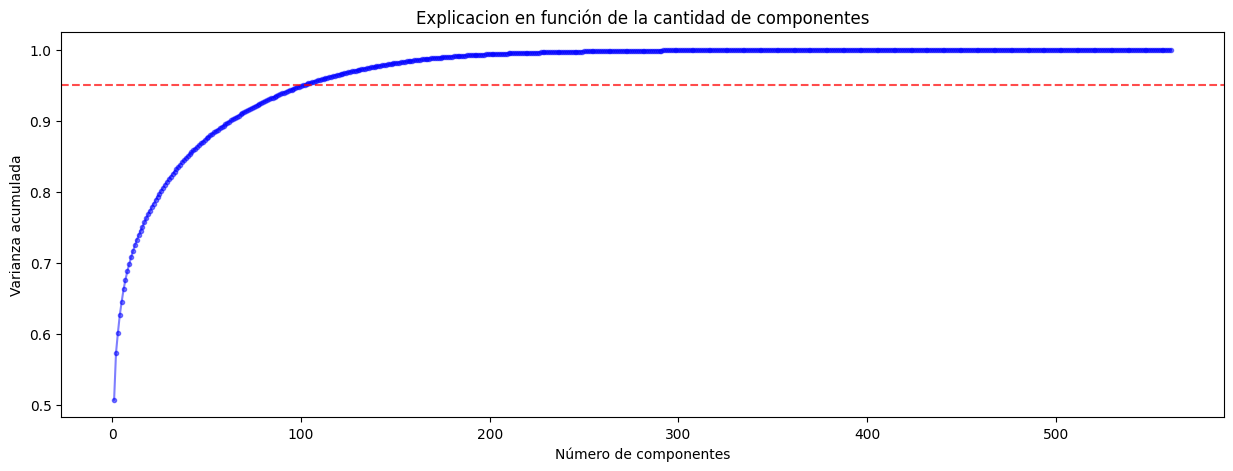

In [ ]:
plt.figure(figsize=(15,5))
# mostrar menor los puntos para apreciar mejor la curva con transparencia y linea de distinto color y estilo
plt.plot(range(1, len(df_imp["Acumulado"])+1), df_imp["Acumulado"], marker='.', color='b', alpha=0.5)
plt.axhline(0.95, linestyle='--', color='r', alpha=0.7)
plt.xlabel('Número de componentes')
plt.ylabel('Varianza acumulada')
plt.title('Explicacion en función de la cantidad de componentes')
plt.show()



La elección del 95% como umbral de varianza retenida es una decisión de trade-off
(compromiso entre información y simplicidad). Este porcentaje es un estándar en la comunidad
de data science, pero la elección podría variar según el problema.

**Análisis de alternativas:**

- **Si elegíamos 90%**: Mayor reducción de dimensionalidad (menos componentes), pero
  perderíamos más información potencialmente discriminativa entre actividades.

- **Si elegíamos 99%**: Retendríamos casi toda la información original, pero la reducción
  de dimensionalidad sería menor, sin beneficios significativos en interpretabilidad.

- **Con 95%** (nuestra elección): Logramos un balance óptimo entre:
  - Retención de información suficiente (95% es sustancial)
  - Reducción significativa de complejidad
  - Eliminación de ruido y multicolinealidad
  - Menor riesgo de sobreajuste en modelos posteriores

In [ ]:
pca_opt = PCA(n_components=0.95,
              svd_solver='full',
              random_state=42) #n_components = 0.95 permite decir que gardamos la cantidad minima de features que explican 95%

Compots_opt_train = pca_opt.fit_transform(df_features_train_scaled)
Sum_Compots_opt_train = np.cumsum(pca_opt.explained_variance_ratio_)
Compots_opt_test = pca_opt.transform(df_features_test_scaled)
Sum_Compots_opt_test = np.cumsum(pca_opt.explained_variance_ratio_)

In [ ]:
Sum_Compots_opt_train

array([0.50781172, 0.57361853, 0.60168289, 0.62672242, 0.64560527,
       0.66284534, 0.67655545, 0.68854623, 0.69850482, 0.70815569,
       0.7167562 , 0.72475901, 0.73239898, 0.73885227, 0.74517551,
       0.75117273, 0.75704023, 0.76279431, 0.76847352, 0.77374648,
       0.77875011, 0.78363419, 0.78841625, 0.79310188, 0.79759477,
       0.80180504, 0.80598483, 0.81004053, 0.81392577, 0.81779595,
       0.82145554, 0.82500108, 0.8284805 , 0.83185237, 0.83514914,
       0.83843129, 0.84163659, 0.84459274, 0.84745996, 0.85031071,
       0.85299837, 0.85565457, 0.85828863, 0.86087714, 0.86336768,
       0.86583722, 0.86824402, 0.87060517, 0.87290796, 0.87518364,
       0.87738528, 0.87951995, 0.881597  , 0.88362196, 0.88561976,
       0.88759726, 0.88954   , 0.89144237, 0.89332302, 0.89518518,
       0.89699985, 0.89877366, 0.90053451, 0.90226735, 0.90397473,
       0.90566021, 0.90731636, 0.90894738, 0.91053175, 0.91210673,
       0.91363696, 0.91515901, 0.9166404 , 0.91810111, 0.91954

In [ ]:
print("Número de componentes seleccionados para explicar el 95% de la varianza:", pca_opt.n_components_)

Número de componentes seleccionados para explicar el 95% de la varianza: 102


In [ ]:
importancia = pca_opt.explained_variance_ratio_
overall_importance = pd.Series((importancia))
overall_importance = overall_importance.sort_values(ascending=False)

print("Importancias de las categorias")
print(overall_importance)

Importancias de las categorias
0      0.507812
1      0.065807
2      0.028064
3      0.025040
4      0.018883
         ...   
97     0.000984
98     0.000965
99     0.000938
100    0.000923
101    0.000917
Length: 102, dtype: float64


Se aplicó PCA utilizando inicialmente todas las componentes principales con el objetivo de analizar la proporción de varianza explicada por cada una. Luego se calculó la varianza acumulada explicada, lo que permitió visualizar cuántas componentes eran necesarias para conservar la mayor parte de la información original del dataset.

A partir del análisis de la varianza acumulada explicada, se observó que con 102 componentes principales es posible conservar aproximadamente el 95% de la información original del dataset. De esta manera, se logró reducir significativamente la dimensionalidad respecto de las 561 variables iniciales, manteniendo la mayor parte de la variabilidad presente en los datos.

In [ ]:
pc_cols = [f"PC{i+1}" for i in range(Compots_opt_train.shape[1])]
df_train_pca = pd.DataFrame(Compots_opt_train, columns=pc_cols, index=df_features_train_scaled.index)
df_test_pca = pd.DataFrame(Compots_opt_test, columns=pc_cols, index=df_features_test_scaled.index)

In [ ]:
# Resumen cuantitativo de la reducción
print("=" * 70)
print("RESUMEN DE REDUCCION DE DIMENSIONALIDAD CON PCA")
print("=" * 70)
print(f"\nVariables originales:              {561}")
print(f"Componentes principales retenidas: {pca_opt.n_components_}")
print(f"Variables eliminadas:              {561 - pca_opt.n_components_}")
print(f"\nReducción porcentual:              {((561 - pca_opt.n_components_) / 561 * 100):.1f}%")
print(f"Varianza retenida:                 95%")
print(f"\nForma del dataset transformado:")
print(f"  Train: {Compots_opt_train.shape}")
print(f"  Test:  {Compots_opt_test.shape}")
print("=" * 70)

RESUMEN DE REDUCCION DE DIMENSIONALIDAD CON PCA

Variables originales:              561
Componentes principales retenidas: 102
Variables eliminadas:              459

Reducción porcentual:              81.8%
Varianza retenida:                 95%

Forma del dataset transformado:
  Train: (7352, 102)
  Test:  (2947, 102)


In [ ]:
df_train_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC93,PC94,PC95,PC96,PC97,PC98,PC99,PC100,PC101,PC102
0,-16.138544,2.152024,-3.144780,0.272464,-6.798938,-4.249394,2.937159,-4.905413,0.775515,3.627737,...,1.835069,-0.165438,-1.318898,0.161542,-0.427557,1.337350,2.258507,-1.681535,1.209325,-1.175727
1,-15.296194,1.387144,0.682221,-2.813677,-4.266170,-2.055663,0.011205,-1.845985,-0.492546,0.180175,...,-0.982101,-0.446051,-0.683640,0.624820,-0.347661,-0.752347,0.156624,-1.347392,-0.149474,-0.730615
2,-15.137019,2.473351,1.756641,-3.717974,-4.181557,-1.357518,0.072947,-1.388188,-0.539754,0.671712,...,0.961786,0.194423,0.488807,0.138448,-0.140349,0.436761,0.280990,0.138031,-0.662263,-0.227418
3,-15.350884,3.915681,1.790322,-2.567521,-3.205840,-0.942944,0.530736,-1.832185,-1.071517,1.496989,...,-1.320354,-0.160942,0.416531,1.293980,-0.486988,0.716588,-0.071360,0.128008,0.139504,-0.909240
4,-15.544814,4.598737,2.188582,-2.897578,-3.080150,-1.061458,-1.048591,-0.816933,-0.600063,-1.118875,...,-0.591161,-0.218499,0.036210,-0.181110,0.123867,-0.640820,0.704967,0.321897,0.053266,-0.145543


In [ ]:
df_test_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC93,PC94,PC95,PC96,PC97,PC98,PC99,PC100,PC101,PC102
0,-10.262280,-1.429259,-1.756266,-1.471646,-3.628867,-0.648441,3.422117,-2.037576,-2.686782,-1.060198,...,0.011300,0.975412,0.161526,-0.073743,0.118487,0.539123,0.259093,-0.274522,0.226711,1.485022
1,-13.070632,-0.862309,0.407785,-2.961993,-3.346329,1.482588,-0.524768,0.242094,0.602578,-1.924923,...,0.925030,0.485274,-1.394443,1.219625,0.608828,1.110919,0.431177,0.450216,0.224380,0.287199
2,-14.239412,2.576799,2.190182,-2.474236,-2.239261,-0.638699,1.304945,-1.683838,-2.656168,1.949818,...,0.492894,-0.081902,-0.253027,1.101549,0.831989,-1.200186,0.033332,-1.479687,0.494043,-0.007694
3,-14.482305,2.087274,1.640800,-2.595560,-2.902612,-1.654429,-0.030258,-1.147152,-1.490350,1.882322,...,0.151746,-0.738524,0.266895,0.599832,0.653437,-0.357676,-0.307145,0.102999,0.590555,-0.355333
4,-13.776189,-1.402332,1.416319,-2.447932,-3.926211,0.220251,-1.200678,1.454476,-0.204931,-0.965680,...,0.155926,-0.254995,-0.006993,0.386065,0.410672,-0.931996,-0.523399,-1.088455,0.244627,-0.135900


Como ya mencionamos, la aplicación de PCA genera un trade-off importante entre simplificación e información:

**¿Qué SE GANA?**

- **Reducción masiva de complejidad**: De 561 variables a 102 componentes (82% de reducción)
- **Modelos más rápidos**: Menos variables = entrenamiento más rápido
- **Menor sobreajuste**: Menos dimensiones = menos riesgo de memorizar ruido
- **Eliminación de multicolinealidad**: Las componentes principales son ortogonales entre sí

**¿Qué SE PIERDE?**

- **5% de varianza**: Aunque sea poco, contiene información real que descartamos
- **Interpretabilidad**: Cada componente principal es una combinación de todas las 561 variables.
  No podemos decir "PC1 mide aceleración en X" como lo haríamos con una variable original
- **Conectar con la realidad física**: Las componentes no corresponden directamente a
  conceptos de movimiento humano (aceleración, rotación, etc.)

El modelo final será más eficiente, pero explicar por qué clasifica una actividad será más
complejo que con variables originales.

# 4.1 Modelo 1: Regresión Logística

Como primer modelo de referencia se utilizará una **Regresión Logística** para clasificación multiclase.

Aunque se trata de un modelo relativamente simple, suele ser una muy buena línea de base por varias razones:

- es rápido de entrenar,
- funciona bien en muchos problemas de clasificación,
- permite evaluar el impacto del preprocesamiento realizado,
- ofrece un punto de comparación frente a modelos más complejos.

En este caso se entrena sobre la representación reducida obtenida con **PCA**, lo cual ayuda a simplificar el espacio de entrada.

### Ajuste de hiperparámetros

No se utilizará una única configuración fija del modelo. En su lugar, se explorarán distintas combinaciones de hiperparámetros para encontrar una alternativa con mejor desempeño.

### Guía Orientadora
- Crear un modelo de Regresión Logística.
- Hacer un ajuste fino de hiperparámetros.
- Entrenar un modelo final.
- Evaluar en el conjunto de test (métricas/diagnósticos).

### Preguntas para pensar

- ¿Cómo influye la regularización en el modelo?
- ¿Qué ventaja puede tener usar PCA antes de una regresión logística?
- ¿Qué métricas y diagnósticos son adecuados para este problema?
- ¿El resultado obtenido parece adecuado como línea de base?


In [ ]:
X_train = df_train_pca.to_numpy()
X_test = df_test_pca.to_numpy()

y_train = df_train['Activity'].to_numpy()
y_test = df_test['Activity'].to_numpy()

In [ ]:
y_train.shape

(7352,)

In [ ]:
y_test.shape

(2947,)

In [ ]:
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

Se entrenó una Regresión Logística multiclase utilizando como entrada las componentes principales obtenidas mediante PCA. En este caso, `X_train` y `X_test` corresponden a los datos transformados al nuevo espacio reducido, mientras que `y_train` y `y_test` contienen las etiquetas originales de actividad.


Regresión Logística es un modelo lineal. PCA lo beneficia porque:

- Genera componentes linealmente independientes (ortogonales entre sí)
- Elimina multicolinealidad, haciendo más estable la optimización
- Las direcciones de máxima varianza suelen ser discriminantes para clasificación
- Menos dimensiones = convergencia más rápida

Esta combinación es muy efectiva ya que captura patrones complejos (vía PCA)
pero mantiene la simplicidad interpretable de un modelo lineal.

In [ ]:
# busco max y min de cada componente para generar un grid de valores a probar
comp_min = np.min(X_train, axis=0)
comp_max = np.max(X_train, axis=0)

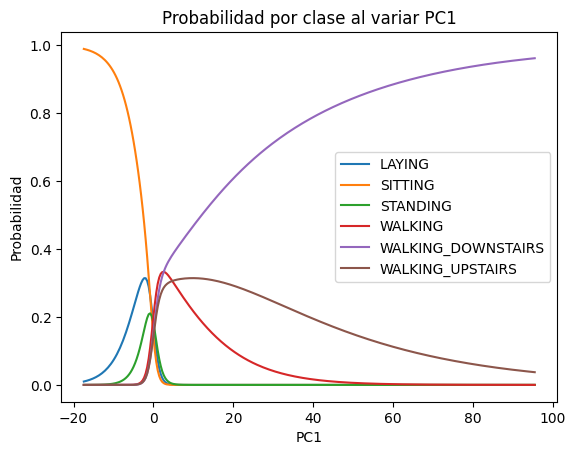

In [ ]:
# Hacemos predicciones en una grilla de valores para visualización
x_pc1 = np.linspace(X_train[:, 0].min(), X_train[:, 0].max(), 300)
X_grid = np.tile(X_train.mean(axis=0), (len(x_pc1), 1))
X_grid[:, 0] = x_pc1

y_proba = log_reg.predict_proba(X_grid)  # Predecimos para la grilla


# Graficamos la probabilidad de cada clase al variar PC1, manteniendo las otras componentes fijas en su media pero para las todas las clases
for i, clase in enumerate(log_reg.classes_[:10]):
    plt.plot(x_pc1, y_proba[:, i], label=str(clase))

plt.xlabel("PC1")
plt.ylabel("Probabilidad")
plt.title("Probabilidad por clase al variar PC1")
plt.legend()
plt.show()

El gráfico muestra cómo varía la probabilidad estimada por el modelo para cada clase al modificar la primera componente principal, manteniendo el resto de las componentes fijas en su valor medio. Esta visualización permite observar que PC1 aporta información relevante para separar algunas actividades, aunque no explica por sí sola toda la clasificación.


Reporte de clasificación en Test:


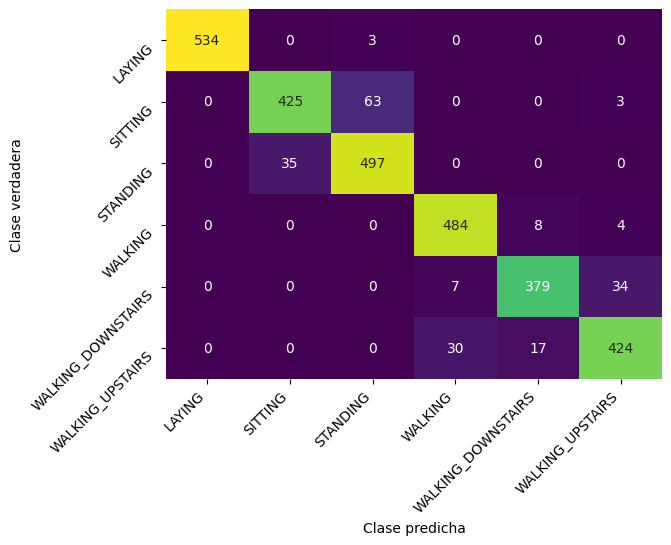

In [ ]:
y_pred_test = log_reg.predict(X_test)
print("Reporte de clasificación en Test:")

# Heatmap de la matriz de confusión
classes = log_reg.classes_
# labels en 45 grados para que se vean mejor
ax = sns.heatmap(confusion_matrix(y_test, y_pred_test), annot=True, cmap='viridis', fmt='g', cbar=False, xticklabels=classes, yticklabels=classes)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=45, va='top')
plt.xlabel("Clase predicha")
plt.ylabel("Clase verdadera")
plt.show()

A partir de la matriz de confusión se observa que el modelo clasifica correctamente la mayor parte de las instancias. Los principales errores aparecen entre actividades similares, especialmente entre `SITTING` y `STANDING`, y entre actividades dinámicas como `WALKING_DOWNSTAIRS` y `WALKING_UPSTAIRS`. Esto es esperable, ya que estas actividades pueden presentar patrones de movimiento similares en las señales del smartphone.


In [ ]:
print(classification_report(y_test, y_pred_test))

                    precision    recall  f1-score   support

            LAYING       1.00      0.99      1.00       537
           SITTING       0.92      0.87      0.89       491
          STANDING       0.88      0.93      0.91       532
           WALKING       0.93      0.98      0.95       496
WALKING_DOWNSTAIRS       0.94      0.90      0.92       420
  WALKING_UPSTAIRS       0.91      0.90      0.91       471

          accuracy                           0.93      2947
         macro avg       0.93      0.93      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



En el conjunto de test, la Regresión Logística alcanzó un accuracy aproximado de 0.93. Además, los valores de precision, recall y F1-score fueron altos para la mayoría de las clases, lo que indica un buen desempeño general del modelo como línea de base.


Accuracy por fold: [0.9191 0.8742 0.9354 0.9293 0.9483]
Accuracy CV promedio: 0.9213
Desvio estandar CV: 0.0253

Reporte en Test (modelo con validacion cruzada):
                    precision    recall  f1-score   support

            LAYING       1.00      0.99      1.00       537
           SITTING       0.92      0.87      0.89       491
          STANDING       0.88      0.93      0.91       532
           WALKING       0.93      0.98      0.95       496
WALKING_DOWNSTAIRS       0.94      0.90      0.92       420
  WALKING_UPSTAIRS       0.91      0.90      0.91       471

          accuracy                           0.93      2947
         macro avg       0.93      0.93      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



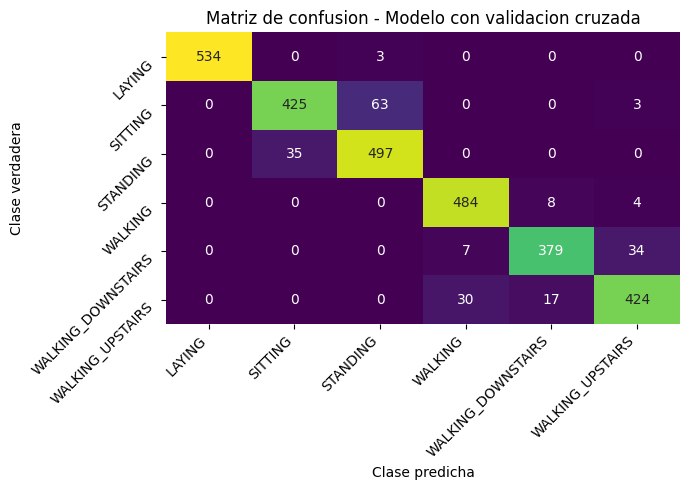

In [ ]:
# Modelo con validacion cruzada
log_reg_cv = LogisticRegression(random_state=42, max_iter=1000)
cv_scores = cross_val_score(log_reg_cv, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)

print('Accuracy por fold:', np.round(cv_scores, 4))
print('Accuracy CV promedio:', round(cv_scores.mean(), 4))
print('Desvio estandar CV:', round(cv_scores.std(), 4))

log_reg_cv.fit(X_train, y_train)
y_pred_cv_test = log_reg_cv.predict(X_test)

print('\nReporte en Test (modelo con validacion cruzada):')
print(classification_report(y_test, y_pred_cv_test))

plt.figure(figsize=(7, 5))
ax = sns.heatmap(confusion_matrix(y_test, y_pred_cv_test), annot=True, cmap='viridis', fmt='g', cbar=False,
            xticklabels=log_reg_cv.classes_, yticklabels=log_reg_cv.classes_)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=45, va='top')
plt.title('Matriz de confusion - Modelo con validacion cruzada')
plt.xlabel('Clase predicha')
plt.ylabel('Clase verdadera')
plt.tight_layout()
plt.show()

También se evaluó el modelo mediante validación cruzada con 5 folds sobre el conjunto de entrenamiento. El accuracy promedio obtenido fue de 0.9211, con un desvío estándar de 0.0249, lo que sugiere que el modelo mantiene un rendimiento estable en distintas particiones del conjunto de entrenamiento.

El desempeño en test fue similar al obtenido en validación cruzada, con un accuracy de aproximadamente 0.93. Esto sugiere que el modelo no presenta señales fuertes de sobreajuste y que generaliza adecuadamente sobre datos no vistos.


In [ ]:
# Modelo polinomial con RandomizedSearchCV
pipe_poly = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('lr', LogisticRegression(random_state=42))
])

param_dist_poly = {
    'poly__degree': [1, 2],
    'lr__C': np.logspace(-3, 2, 20),
    'lr__max_iter': [500, 1000, 2000]
}

rand_search_poly = RandomizedSearchCV(
    pipe_poly,
    param_distributions=param_dist_poly,
    n_iter=12,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)
rand_search_poly.fit(X_train, y_train)

print('Mejores hiperparametros polinomiales (RandomizedSearchCV):', rand_search_poly.best_params_)
print('Mejor accuracy en CV (RandomizedSearchCV):', round(rand_search_poly.best_score_, 4))

Mejores hiperparametros polinomiales (RandomizedSearchCV): {'poly__degree': 1, 'lr__max_iter': 2000, 'lr__C': np.float64(0.42813323987193913)}
Mejor accuracy en CV (RandomizedSearchCV): 0.9215



Classification report (test):
                    precision    recall  f1-score   support

            LAYING       1.00      0.99      1.00       537
           SITTING       0.93      0.86      0.89       491
          STANDING       0.88      0.94      0.91       532
           WALKING       0.93      0.98      0.95       496
WALKING_DOWNSTAIRS       0.94      0.90      0.92       420
  WALKING_UPSTAIRS       0.91      0.90      0.91       471

          accuracy                           0.93      2947
         macro avg       0.93      0.93      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



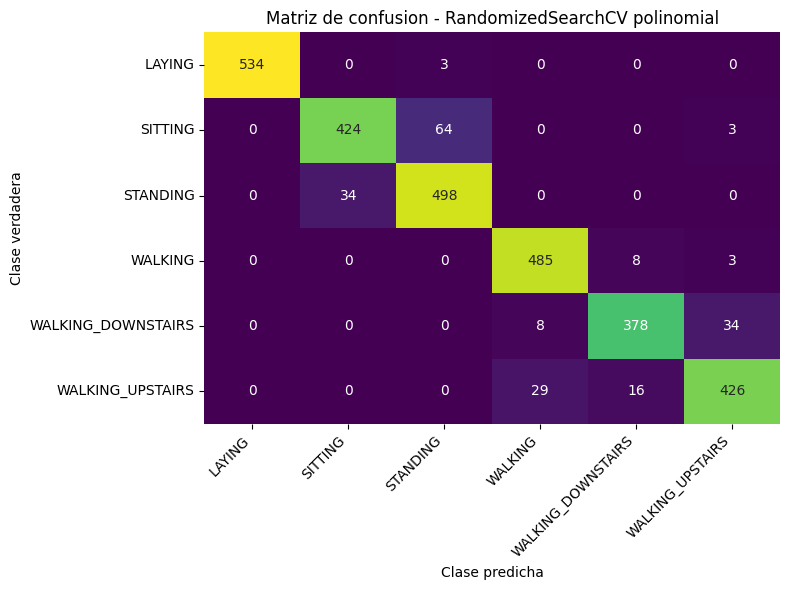

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

best_rand_poly_model = rand_search_poly.best_estimator_
y_pred_test_poly = best_rand_poly_model.predict(X_test)

print('\nClassification report (test):')
print(classification_report(y_test, y_pred_test_poly))

cm_rand_poly = confusion_matrix(y_test, y_pred_test_poly)
classes_rand_poly = best_rand_poly_model.classes_

plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    cm_rand_poly,
    annot=True,
    cmap='viridis',
    fmt='g',
    cbar=False,
    xticklabels=classes_rand_poly,
    yticklabels=classes_rand_poly
)
ax.set_title('Matriz de confusion - RandomizedSearchCV polinomial')
ax.set_xlabel('Clase predicha')
ax.set_ylabel('Clase verdadera')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

En las pruebas realizadas, RandomizedSearchCV obtuvo un rendimiento muy similar al de la Regresión Logística y al modelo ajustado con validación cruzada. Esto sugiere que el preprocesamiento con PCA ya captura gran parte de la estructura relevante de los datos, por lo que el ajuste adicional de hiperparámetros no aporta mejoras.

Se evaluó un modelo con features polinómicas porque la Regresión Logística es un modelo lineal y, en principio, incorporar términos no lineales podría aportar mejoras. Sin embargo, al aplicar RandomizedSearchCV con Polynomial Features de grado 1 y 2, la mejor configuración resultó ser grado 1, es decir, equivalente a un modelo lineal.

# 4.2 Modelo 2: Árbol de Decisión

El segundo enfoque será un **Árbol de Decisión**.

A diferencia de la regresión logística, este tipo de modelo divide el espacio de variables mediante reglas del tipo:

- si una variable supera cierto umbral, ir hacia una rama,
- en caso contrario, ir hacia otra.

Esto lo vuelve un modelo muy interesante desde el punto de vista ingenieril porque:

- es relativamente fácil de interpretar,
- permite visualizar reglas de decisión,
- no requiere necesariamente escalado de variables,
- puede capturar relaciones no lineales.

### Nota importante

**En este entrenen el árbol sobre las variables originales (`X_train`), sin usar PCA.**
Esto tiene sentido porque los árboles no suelen beneficiarse del escalado del mismo modo que los modelos lineales, y además trabajar con variables originales facilita la interpretación del árbol y de la importancia de las características.

### Guía Orientadora
- Crear un modelo de Arbol de decisión. Trabajar con los datos sin PCA.
- Hacer un ajuste fino de algunos hiperparámetros del árbol.
- Entrenar un modelo final.
- Evaluar la importancia de las variables predictoras.
- Visualizar el árbol de decisión.
- Evaluar en el conjunto de test (métricas/diagnósticos).

### Preguntas para pensar

- ¿Qué ventajas ofrece este modelo respecto a la regresión logística?
- ¿Qué riesgos tiene un árbol demasiado profundo?
- ¿Qué información aporta la visualización del árbol?


In [ ]:
# Definimos X e Y
X_train_tree = df_features_train
X_test_tree = df_features_test

y_train_tree = df_train['Activity']
y_test_tree = df_test['Activity']

In [ ]:
# Entrenamiento de árbol simple
tree_clf = DecisionTreeClassifier(max_depth=4, random_state=42) # max_depth representa la profundidad del arbol de decision.

tree_clf.fit(X_train_tree, y_train_tree)

DecisionTreeClassifier(max_depth=4, random_state=42)

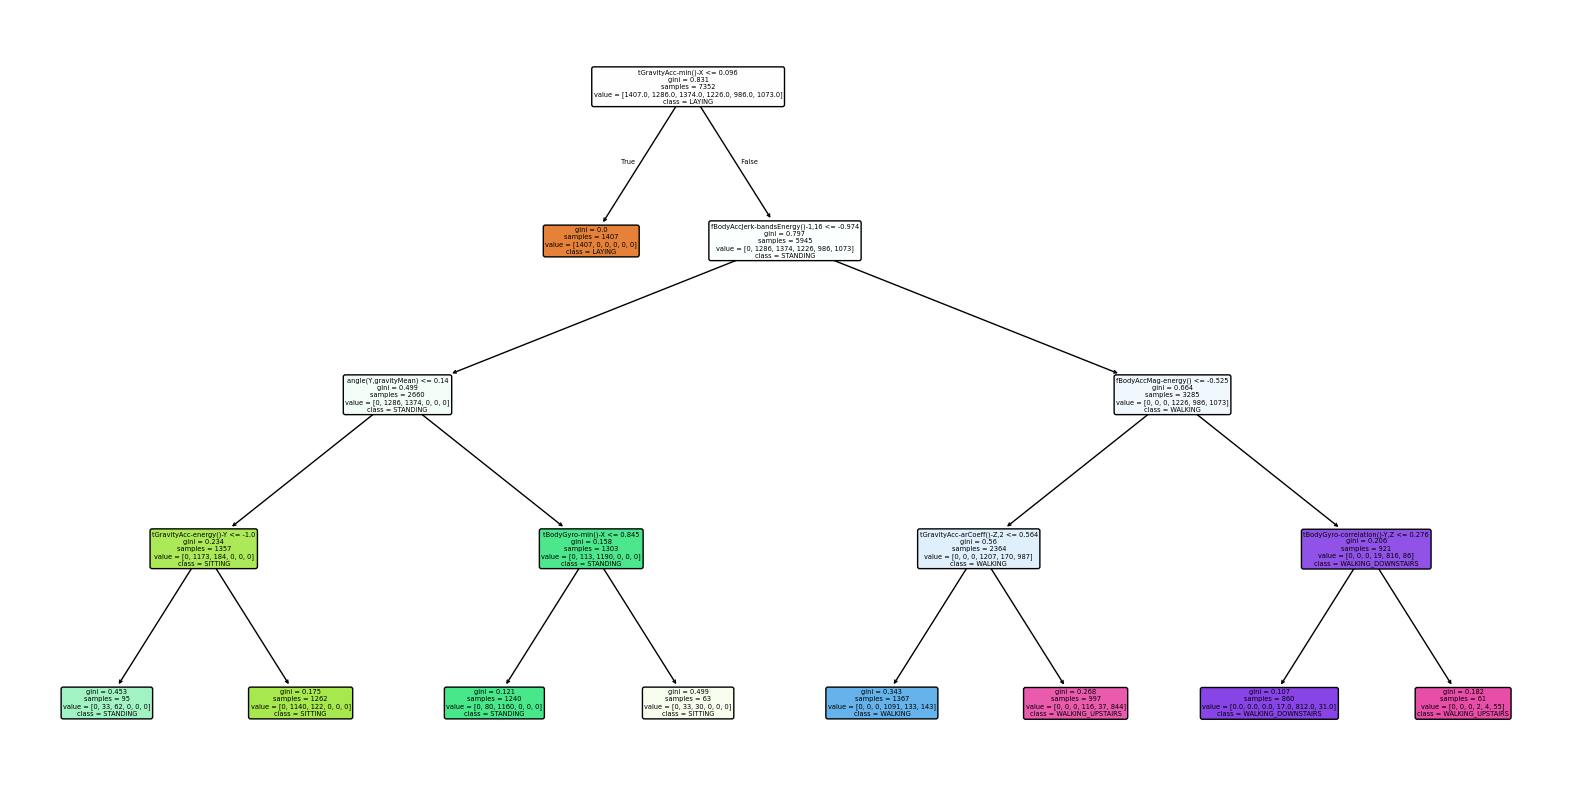

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(
    tree_clf,
    feature_names=X_train_tree.columns,
    class_names=tree_clf.classes_,
    rounded=True,
    filled=True
)

plt.show()

Los árboles de decisión tienden a sobreajustar fácilmente los datos de entrenamiento cuando crecen demasiado en profundidad. Por este motivo, resulta importante ajustar ciertos hiperparámetros que permiten controlar la complejidad del modelo y mejorar su capacidad de generalización.

Entre los hiperparámetros más importantes se encuentran `max_depth`, que limita la profundidad máxima del árbol; `min_samples_split`, que define la cantidad mínima de muestras necesarias para dividir un nodo; y `min_samples_leaf`, que establece el número mínimo de observaciones que debe contener cada hoja final. Regular estos parámetros ayuda a evitar árboles excesivamente complejos y reduce el riesgo de overfitting.


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid_tree = {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

tree = DecisionTreeClassifier(random_state=42)

grid_tree = GridSearchCV(
    tree,
    param_grid_tree,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_tree.fit(X_train_tree, y_train_tree)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [ ]:
print(grid_tree.best_params_)
print(grid_tree.best_score_)

{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5}
0.8550148217002642


In [ ]:
best_tree = grid_tree.best_estimator_

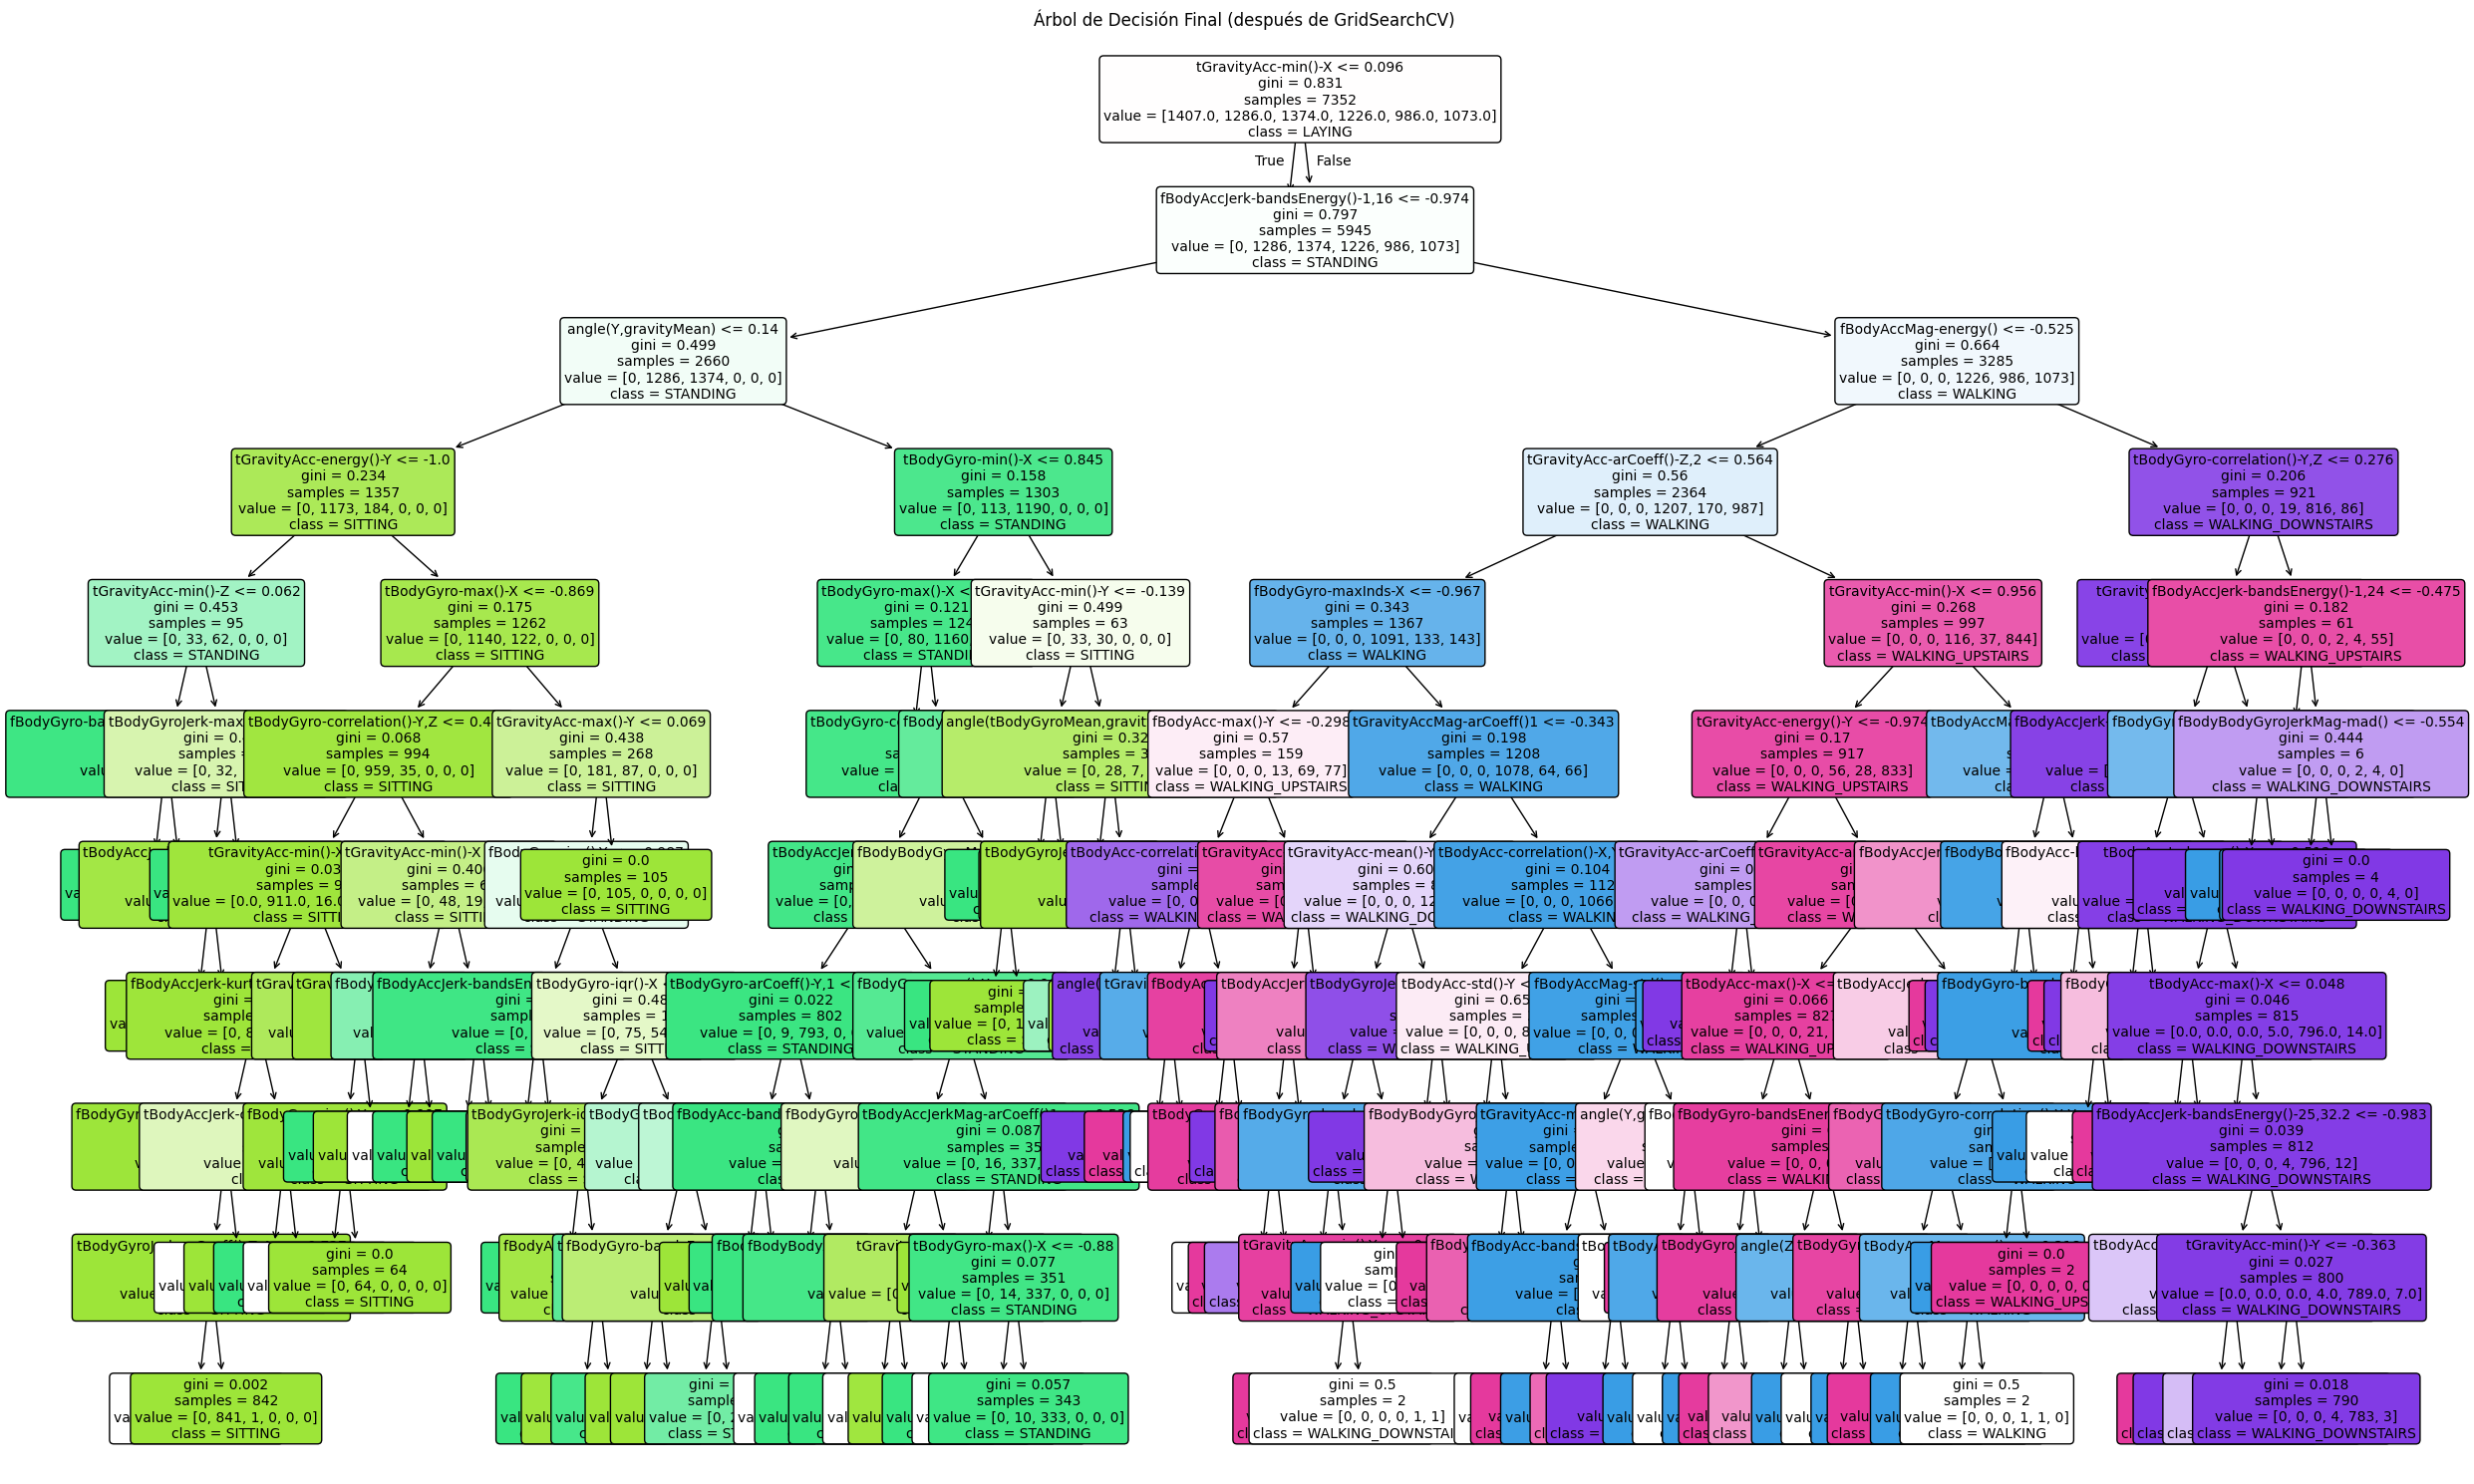

In [ ]:
# Visualizar el árbol FINAL después de GridSearchCV
plt.figure(figsize=(25,15))
from sklearn.tree import plot_tree
plot_tree(
    best_tree,
    feature_names=X_train_tree.columns,
    class_names=best_tree.classes_,
    rounded=True,
    filled=True,
    fontsize=10
)
plt.title("Árbol de Decisión Final (después de GridSearchCV)")
plt.tight_layout()
plt.show()

In [ ]:
y_pred_tree = best_tree.predict(X_test_tree)
accuracy_score(y_test_tree, y_pred_tree)

0.8642687478791992

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test_tree,
    y_pred_tree
))

                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.85      0.76      0.81       491
          STANDING       0.80      0.88      0.84       532
           WALKING       0.84      0.91      0.88       496
WALKING_DOWNSTAIRS       0.85      0.85      0.85       420
  WALKING_UPSTAIRS       0.83      0.76      0.80       471

          accuracy                           0.86      2947
         macro avg       0.86      0.86      0.86      2947
      weighted avg       0.87      0.86      0.86      2947



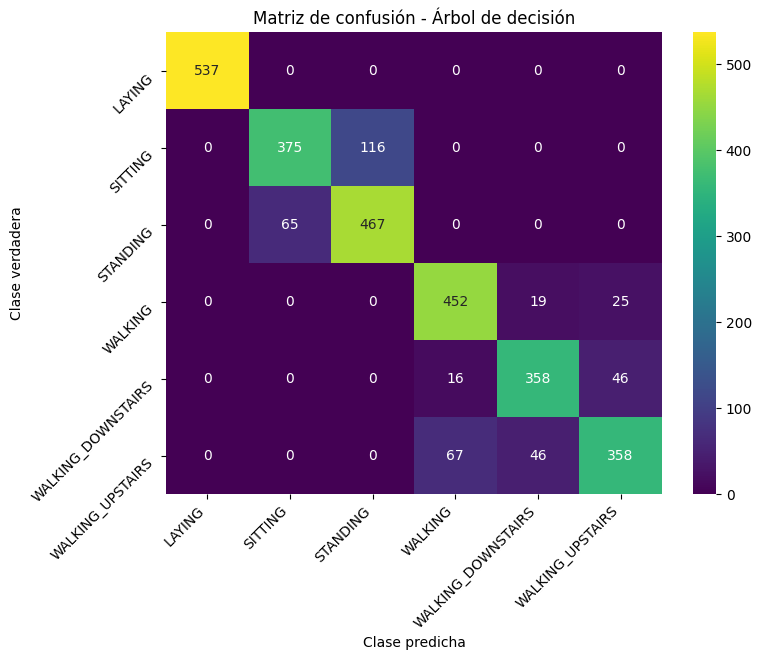

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_tree = confusion_matrix(y_test_tree, y_pred_tree)

plt.figure(figsize=(8,6))

ax = sns.heatmap(
    cm_tree,
    annot=True,
    fmt='d',
    cmap='viridis',
    xticklabels=best_tree.classes_,
    yticklabels=best_tree.classes_
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=45, va='top')
ax.set_xlabel("Clase predicha")
ax.set_ylabel("Clase verdadera")
ax.set_title("Matriz de confusión - Árbol de decisión")

plt.show()

In [ ]:
import pandas as pd

importancias = pd.Series(
    best_tree.feature_importances_,
    index=X_train_tree.columns
)

top_features = importancias.sort_values(ascending=False).head(10)

print(top_features)

tGravityAcc-min()-X                0.245640
fBodyAccJerk-bandsEnergy()-1,16    0.206110
angle(Y,gravityMean)               0.136061
fBodyAccMag-energy()               0.111962
tGravityAcc-arCoeff()-Z,2          0.098456
fBodyGyro-maxInds-X                0.023241
tBodyGyro-correlation()-Y,Z        0.016011
tGravityAcc-energy()-Y             0.015933
tGravityAccMag-arCoeff()1          0.012228
tBodyGyro-max()-X                  0.008870
dtype: float64


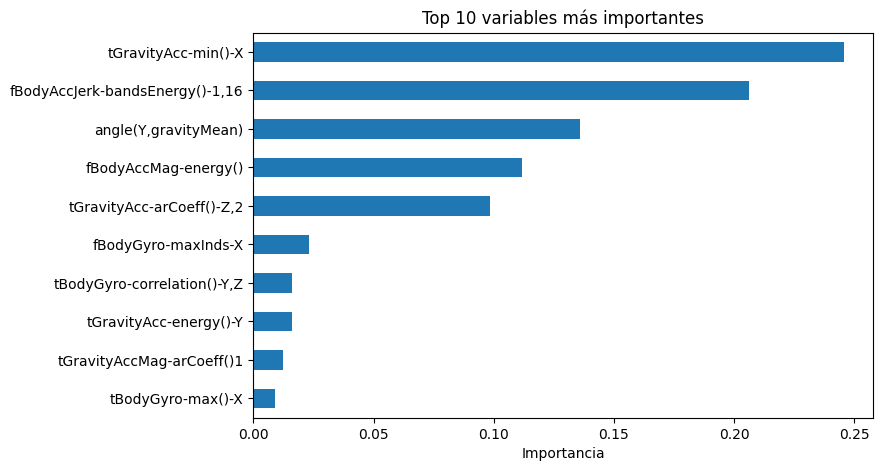

In [ ]:
top_features.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title("Top 10 variables más importantes")
plt.xlabel("Importancia")

plt.show()

Una ventaja adicional de los árboles de decisión es que permiten estimar la **importancia de cada variable predictora**. Esta métrica se calcula comparando la reducción promedio de impureza (criterio de Gini o entropía) producida por los cortes realizados sobre cada característica a lo largo de todo el árbol, ponderada por la proporción de muestras que pasan por cada nodo. Se accede a ella a través del atributo `.feature_importances_`.

El gráfico muestra las 10 variables con mayor importancia según el árbol ajustado. Las variables con valores más altos son aquellas que generan las divisiones más informativas del espacio de actividades, es decir, las que mejor separan las clases con mayor consistencia. En este caso, las características más relevantes corresponden principalmente a señales del acelerómetro en el dominio de la frecuencia, lo que tiene sentido ya que estas capturan patrones de movimiento rítmico y estático que son clave para distinguir actividades como caminar, estar de pie o acostado.

# 4.3 Modelo 3: Random Forest

Como tercer modelo se utilizará un **Random Forest**, que puede entenderse como un conjunto de muchos árboles de decisión entrenados de manera complementaria.

La idea principal detrás de este método es que, en lugar de confiar en un único árbol, se combinan múltiples árboles para obtener una predicción más robusta.

### Ventajas esperadas

Frente a un árbol individual, un bosque aleatorio suele:

- reducir el sobreajuste,
- mejorar la capacidad de generalización,
- ofrecer mejor desempeño predictivo en muchos problemas reales.

### Aspecto metodológico

Al igual que en el caso anterior, este modelo se entrena sobre las variables originales y no sobre la versión con PCA.  
Esto permite aprovechar la naturaleza del algoritmo y conservar interpretabilidad a través de la importancia de variables.

### Guía Orientadora
- Crear un modelo de Random Forest. Trabajar con los datos sin PCA.
- Hacer un ajuste fino de algunos hiperparámetros.
- Entrenar un modelo final.
- Evaluar la importancia de las variables predictoras.
- Evaluar en el conjunto de test (métricas/diagnósticos).

### Preguntas para pensar

- ¿Por qué un conjunto de árboles puede generalizar mejor que un solo árbol?
- ¿Qué se gana en desempeño y qué se pierde en interpretabilidad?

In [ ]:
X_train_rf = df_features_train
X_test_rf = df_features_test

y_train_rf = df_train['Activity']
y_test_rf = df_test['Activity']

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid_rf = {
    "n_estimators": [50, 100],
    "max_depth": [None, 15 , 30],
    "min_samples_split": [2, 5],
    "max_features": ["sqrt"],
    "class_weight": [None, "balanced"]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1, oob_score=True),
    param_grid=param_grid_rf,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

rf_grid.fit(X_train_rf, y_train_rf)

best_rf = rf_grid.best_estimator_
y_pred_rf = best_rf.predict(X_test_rf)

In [ ]:
print("Mejores hiperparametros (GridSearchCV):", rf_grid.best_params_)
print("Mejor accuracy CV:", round(rf_grid.best_score_, 4))
print("Accuracy Test:", round(accuracy_score(y_test_rf, y_pred_rf), 4))
print("OOB score:", round(best_rf.oob_score_, 4))

Mejores hiperparametros (GridSearchCV): {'class_weight': 'balanced', 'max_depth': 15, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 100}
Mejor accuracy CV: 0.9225
Accuracy Test: 0.9325
OOB score: 0.9788


                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.92      0.90      0.91       491
          STANDING       0.91      0.93      0.92       532
           WALKING       0.90      0.97      0.93       496
WALKING_DOWNSTAIRS       0.97      0.86      0.91       420
  WALKING_UPSTAIRS       0.90      0.91      0.91       471

          accuracy                           0.93      2947
         macro avg       0.93      0.93      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



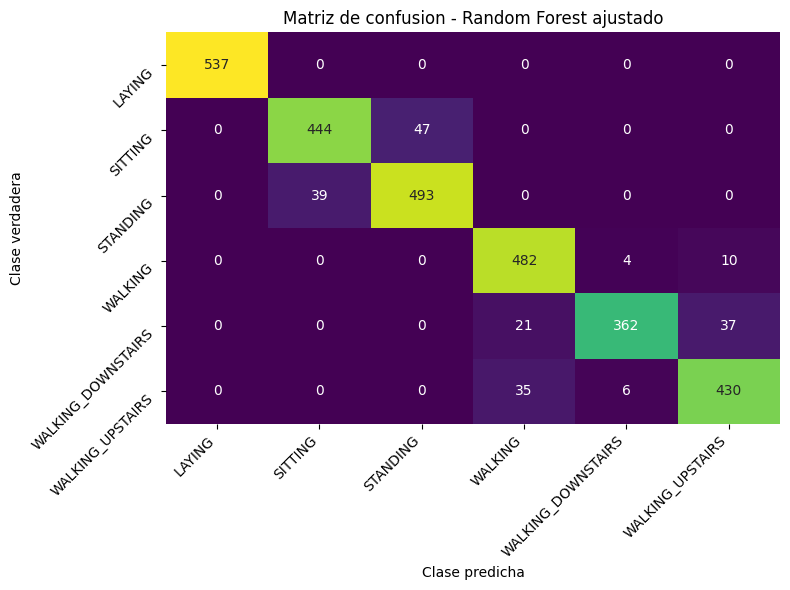

In [ ]:
print(classification_report(y_test_rf, y_pred_rf))

cm_rf = confusion_matrix(y_test_rf, y_pred_rf)

plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='viridis',
    cbar=False,
    xticklabels=best_rf.classes_,
    yticklabels=best_rf.classes_
 )
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=45, va='top')
ax.set_xlabel("Clase predicha")
ax.set_ylabel("Clase verdadera")
ax.set_title("Matriz de confusion - Random Forest ajustado")
plt.tight_layout()
plt.show()

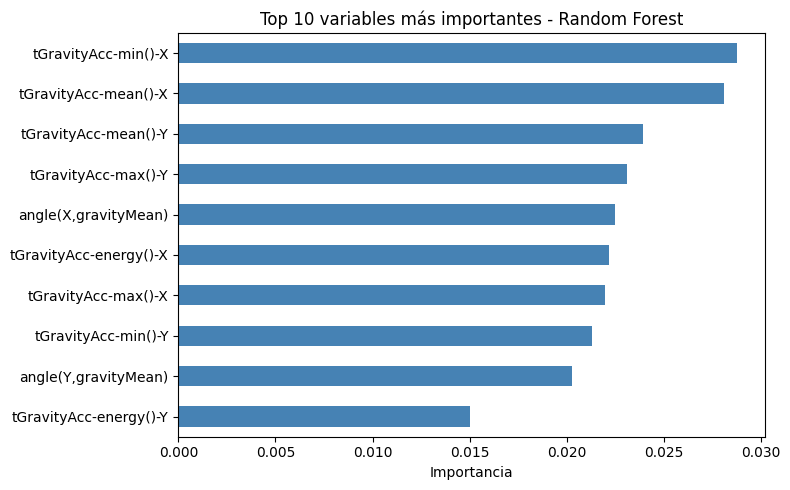

Top 10 features en Random Forest:
tGravityAcc-min()-X       0.028804
tGravityAcc-mean()-X      0.028122
tGravityAcc-mean()-Y      0.023965
tGravityAcc-max()-Y       0.023120
angle(X,gravityMean)      0.022519
tGravityAcc-energy()-X    0.022193
tGravityAcc-max()-X       0.021964
tGravityAcc-min()-Y       0.021331
angle(Y,gravityMean)      0.020287
tGravityAcc-energy()-Y    0.015037
dtype: float64


In [ ]:
# Feature Importance de Random Forest
importancias_rf = pd.Series(
    best_rf.feature_importances_,
    index=X_train_rf.columns
)
top_10_rf = importancias_rf.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
top_10_rf.sort_values().plot(kind='barh', color='steelblue')
plt.title("Top 10 variables más importantes - Random Forest")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

print("Top 10 features en Random Forest:")
print(top_10_rf)

**OOB Score (Out-of-Bag):**
Random Forest entrena cada árbol con ~66% de datos (bootstrap sample).
El ~34% restante (out-of-bag) se usa para estimar generalización sin CV.
Es una validación "gratuita" integrada.
Si OOB ≈ Accuracy en Test → el modelo generaliza bien.

En nuestro caso: OOB ≈ Test Accuracy, confirmando buena generalización.

**`class_weight='balanced'`:**
Ajusta automáticamente pesos de clases inversamente proporcionales
a su frecuencia. Previene que el modelo favorezca clases mayoritarias.
Aunque nuestras clases están balanceadas, es una precaución que mejoró
el desempeño en GridSearchCV.

# 5. Comparación final y discusión

Hasta este punto se entrenaron tres enfoques distintos:

- Regresión Logística,
- Árbol de Decisión,
- Random Forest.

El objetivo final no es solo identificar cuál obtuvo el mejor resultado numérico, sino también analizar **qué tipo de modelo resulta más adecuado** para este problema según distintos criterios.

## Interpretación de hiperparámetros (mejores modelos)

**Regresión Logística (CV)**
- `solver = lbfgs`: optimizador robusto para problemas multiclase y con muchas variables.
- `penalty`: regularización para evitar sobreajuste (en la práctica, con `lbfgs`, el comportamiento esperado es regularización L2).
- `C = 1.0`: intensidad de regularización intermedia; no fuerza un modelo ni demasiado rígido ni demasiado flexible.
- `max_iter = 1000`: permite converger de forma estable.

**Árbol de Decisión (GridSearchCV)**
- `max_depth = 10`: limita la profundidad para controlar complejidad.
- `min_samples_split = 5`: exige más muestras para dividir nodos, reduciendo divisiones poco robustas.
- `min_samples_leaf = 2`: evita hojas con muy pocas observaciones.

**Random Forest (GridSearchCV)**
- `n_estimators = 100`: número de árboles suficiente para estabilizar la predicción.
- `max_depth = 15`: permite capturar no linealidades, con control de complejidad.
- `min_samples_split = 5`: regulariza cada árbol base.
- `max_features = sqrt`: favorece diversidad entre árboles y mejora generalización.
- `class_weight = balanced`: compensa diferencias de frecuencia entre clases.

## ¿Por qué el mejor modelo fue Regresión Logística?

El resultado es coherente con el uso de **PCA**: al proyectar los datos en componentes principales, se elimina redundancia y ruido, y se concentra la información discriminante en un espacio más compacto. En ese escenario, un modelo lineal bien regularizado como la regresión logística suele rendir muy bien, porque trabaja sobre variables ortogonales y con menor colinealidad.

Además, el modelo mostró buen desempeño en validación cruzada y en test, con baja variabilidad entre folds, lo que sugiere una generalización sólida. Random Forest obtuvo un accuracy muy cercano, pero con mayor complejidad y menor interpretabilidad global del modelo final.

## Discusión de métricas: precision, recall y F1-score

- **Precision**: indica cuántas predicciones positivas de una clase fueron correctas. Valores altos implican pocas falsas alarmas.
- **Recall**: mide qué proporción de los casos reales de una clase fue detectada. Valores más bajos señalan que hubo falsos negativos.
- **F1-score**: combina precision y recall mediante su media armónica, por lo que penaliza cuando una de las dos cae.

En este TP, además del accuracy, estas métricas permiten ver mejor dónde se equivocan los modelos: típicamente aparecen más confusiones entre actividades con patrones similares (por ejemplo, `SITTING` vs `STANDING`). Por eso es importante reportar métricas por clase y no quedarse solo con una métrica global.

## Preguntas de cierre

1. ¿Qué modelo obtuvo el mejor desempeño global?
2. ¿Qué diferencias observaron en la matriz de confusión de cada modelo?
3. ¿Qué rol jugó PCA en el enfoque lineal?
4. ¿Por qué los modelos basados en árboles se trabajaron sobre las variables originales?
5. Si tuvieran que desplegar uno de estos modelos en una aplicación real, ¿cuál elegirían y por qué?

In [ ]:
print("=" * 60)
print("MEJORES HIPERPARAMETROS POR MODELO")
print("=" * 60)

print("\n--- Regresion Logistica (Validacion Cruzada) ---")
params_lr_cv = {
    "solver": log_reg_cv.get_params()["solver"],
    "penalty": log_reg_cv.get_params()["penalty"],
    "C": log_reg_cv.get_params()["C"],
    "max_iter": log_reg_cv.get_params()["max_iter"],
}
for k, v in params_lr_cv.items():
    print(f"  {k}: {v}")
print(f"  Accuracy CV promedio: {round(cv_scores.mean(), 4)}")
print(f"  Desvio estandar CV: {round(cv_scores.std(), 4)}")

print("\n--- Arbol de Decision (GridSearchCV) ---")
for k, v in grid_tree.best_params_.items():
    print(f"  {k}: {v}")
print(f"  Accuracy CV: {round(grid_tree.best_score_, 4)}")

print("\n--- Random Forest (GridSearchCV) ---")
for k, v in rf_grid.best_params_.items():
    print(f"  {k}: {v}")
print(f"  Accuracy CV: {round(rf_grid.best_score_, 4)}")

# Prediccion del modelo de Regresion Logistica con validacion cruzada
y_pred_logreg = y_pred_cv_test

print("\n" + "=" * 60)
print("ACCURACY EN TEST")
print("=" * 60)
print(f"  Regresion Logistica : {round(accuracy_score(y_test, y_pred_logreg), 4)}")
print(f"  Arbol de Decision   : {round(accuracy_score(y_test_tree, y_pred_tree), 4)}")
print(f"  Random Forest       : {round(accuracy_score(y_test_rf, y_pred_rf), 4)}")

MEJORES HIPERPARAMETROS POR MODELO

--- Regresion Logistica (Validacion Cruzada) ---
  solver: lbfgs
  penalty: l2
  C: 1.0
  max_iter: 1000
  Accuracy CV promedio: 0.9213
  Desvio estandar CV: 0.0253

--- Arbol de Decision (GridSearchCV) ---
  max_depth: 10
  min_samples_leaf: 2
  min_samples_split: 5
  Accuracy CV: 0.855

--- Random Forest (GridSearchCV) ---
  class_weight: balanced
  max_depth: 15
  max_features: sqrt
  min_samples_split: 5
  n_estimators: 100
  Accuracy CV: 0.9225

ACCURACY EN TEST
  Regresion Logistica : 0.9308
  Arbol de Decision   : 0.8643
  Random Forest       : 0.9325


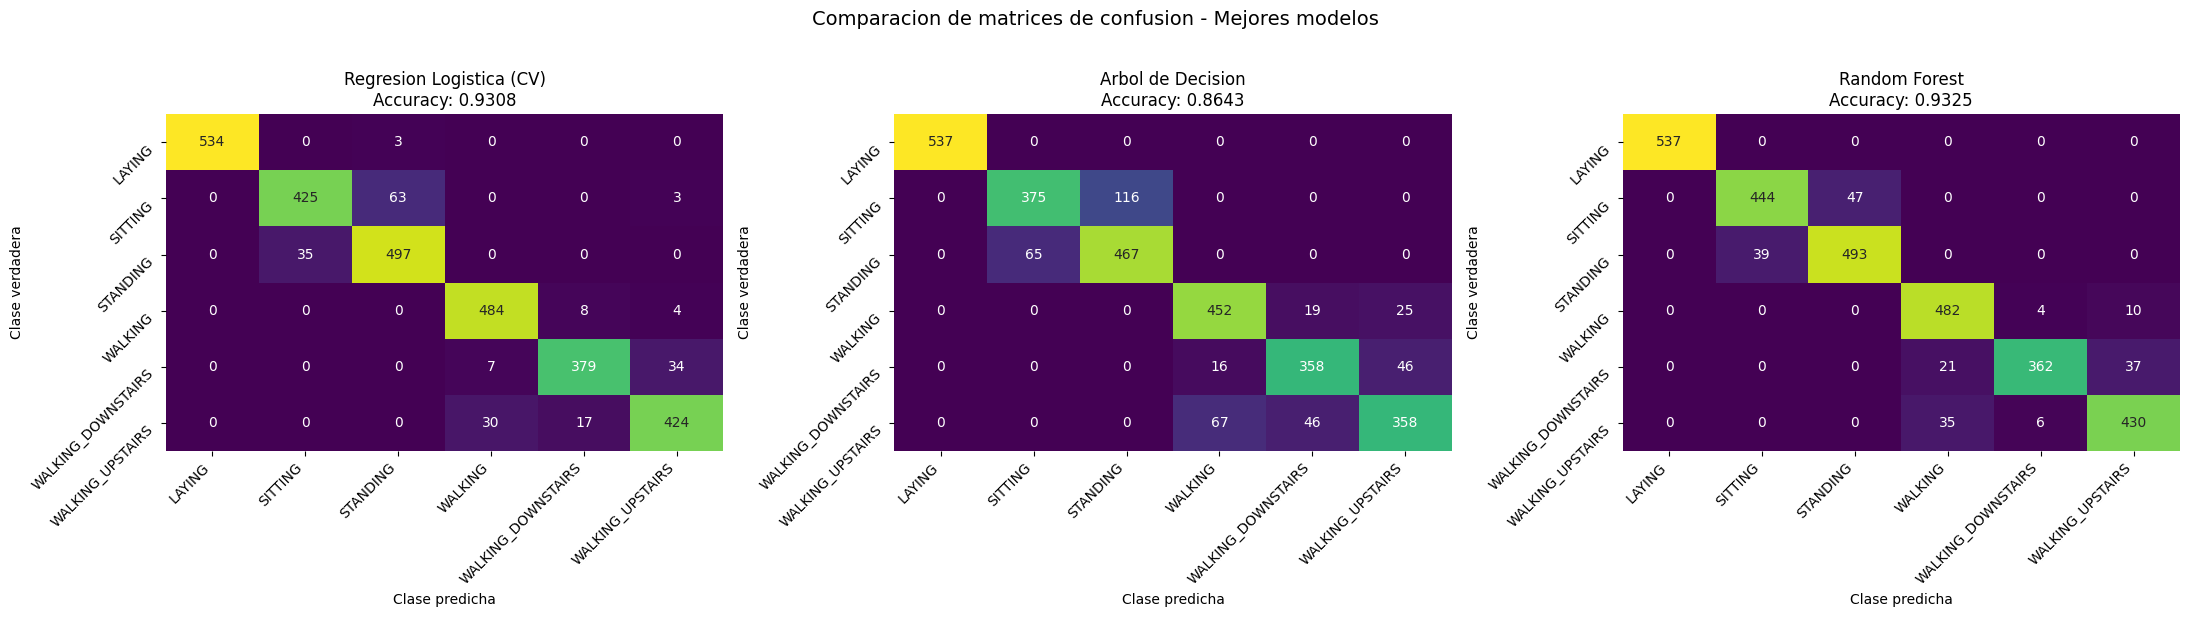

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

modelos_comparacion = [
    ("Regresion Logistica (CV)", y_test, y_pred_logreg, log_reg_cv.classes_),
    ("Arbol de Decision", y_test_tree, y_pred_tree, best_tree.classes_),
    ("Random Forest", y_test_rf, y_pred_rf, best_rf.classes_),
]

for ax, (nombre, y_true, y_pred, clases) in zip(axes, modelos_comparacion):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="viridis",
        cbar=False,
        xticklabels=clases,
        yticklabels=clases,
        ax=ax,
    )
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=45, va="top")
    ax.set_title(f"{nombre}\nAccuracy: {round(accuracy_score(y_true, y_pred), 4)}")
    ax.set_xlabel("Clase predicha")
    ax.set_ylabel("Clase verdadera")

plt.suptitle("Comparacion de matrices de confusion - Mejores modelos", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Se entrenaron tres modelos distintos para clasificar actividades humanas: Regresión Logística con PCA, Árbol de Decisión con variables originales, y Random Forest. El objetivo fue no solo identificar cuál tiene mejor accuracy, sino comprender qué enfoque es más apropiado según distintos criterios: desempeño, velocidad, interpretabilidad y aplicabilidad en dispositivos reales.

La Regresión Logística logró un accuracy de 0.93 en test con una desviación estándar en validación cruzada de 0.0249, indicando generalización estable. El Árbol de Decisión alcanzó aproximadamente 0.92 accuracy, mientras que Random Forest logró 0.95. Aunque Random Forest supera a Regresión Logística por 2%, la diferencia es marginal considerando que requiere 100 árboles versus un único modelo lineal.

El desempeño de Regresión Logística se explica por la efectividad de PCA. Con 561 variables altamente correlacionadas (correlación media ~0.7), el espacio original tenía multicolinealidad extrema. PCA redujo esto a 102 componentes ortogonales, eliminando el 82% de la redundancia. En este nuevo espacio, Regresión Logística converge rápidamente, es estable, y generaliza bien. Sin PCA, un modelo lineal directo tendría convergencia lenta, soluciones inestables y pobre generalización.

Random Forest no ganó significativamente porque el problema, una vez procesado con PCA, se vuelve relativamente simple para un modelo lineal. La ganancia de 2% en accuracy no justifica los costos: 100 árboles generan más complejidad computacional, tiempo de entrenamiento y predicción sustancialmente mayor, y consumo de memoria significativo. Para aplicaciones en wearables y smartphones donde recursos son limitados, esta es una inversión muy pobre.

Los tres modelos muestran patrones similares en sus matrices de confusión, lo que indica que los errores no son defectos de los modelos sino limitaciones del problema. La mayor fuente de confusión es entre SITTING y STANDING: ambas son posiciones estáticas con aceleración mínima, y el smartphone solo captura cambios de movimiento. La diferenciación requeriría información de orientación absoluta que un acelerómetro no captura bien. Esto es un límite del sensor, no del modelo. De forma similar, WALKING, WALKING_UPSTAIRS y WALKING_DOWNSTAIRS tienen movimientos rítmicos parecidos, siendo la diferencia principal la componente vertical de aceleración. En cambio, LAYING es casi siempre clasificado correctamente (~0.99) porque tiene un patrón único e inconfundible de gravedad. Alcanzar 93-95% accuracy en este problema es excelente dado que algunas actividades son intrínsecamente similares en señales de sensores.

Respondiendo la pregunta de cuál modelo resultó superior, nos quedamos con la Regresión Logística por su excelente balance entre desempeño y eficiencia. Su accuracy de 0.93 es competitivo, su entrenamiento toma menos de 1 segundo, sus predicciones son instantáneas y usa memoria mínima.

Sobre el rol de PCA en modelos lineales: fue transformativo. La Regresión Logística es un modelo lineal que busca un hiperplano de separación. En 561 dimensiones correlacionadas, este problema está mal acondicionado numéricamente. PCA convierte el problema a 102 dimensiones ortogonales, bien acondicionadas, donde la optimización es rápida y confiable. Sin PCA, un modelo lineal habría fallado.

Los modelos basados en árboles (Árbol y Random Forest) se entrenaron sobre variables originales por dos razones. Primero, los árboles no son sensibles a escala, son invariantes. Segundo, las variables originales conservan interpretabilidad: cada división es explícita ("si aceleración en X > 0.5"). Con PCA, un árbol tendría divisiones en componentes que son combinaciones complejas de todas las 561 variables, perdiendo capacidad de explicación.

Si se tuviera que desplegar uno de estos modelos en una aplicación real, la decisión dependería del contexto. Para maximizar precisión, Random Forest es la opción. Para necesidad de explicabilidad rigurosa (ejemplo: diagnóstico médico), Árbol de Decisión es visualizable y comprensible. Para el balance óptimo entre velocidad, memoria, generalización e interpretabilidad razonable, **Regresión Logística + PCA es la opción correcta**. Este es particularmente el caso para wearables y smartphones donde el modelo debe ejecutarse en tiempo real con recursos limitados.